# 验证 NinaPro T=40 脉冲编码

本 Notebook 从 train 和 test 合并候选中，为 Exercise A 的12个动作各随机选择一个窗口，并用固定随机种子选择同一组4个通道。

每条通道序列执行三方对比：

1. V3 Vin 输入由 System_with_TIA.asc 拓扑和参数导出的 LTspice 批处理网表；
2. 相同 Vin 输入 system_with_tia.py；
3. 读取 ninapro_data/neurophic_system_spikes/offset_128/T_40 中对应样本的已编码结果。

验证规则：

- Python重算必须与T_40中的二值脉冲和分箱计数逐元素一致；
- LTspice与Python使用相同的1.55 V武装、下降穿越1.25 V、0.5 ms不应期规则；
- LTspice与Python波形不要求逐点相同，使用相关系数、RMSE和脉冲分箱一致率量化差异；
- 原始System_with_TIA.asc不会被修改，所有PWL、网表和RAW均位于临时目录。


In [1]:
# 1. 参数、依赖和项目路径
T = 40
RANDOM_SEED = 42
CHANNELS_TO_SELECT = 4
LTSPICE_EXECUTABLE_TEXT = r"D:\Software\LTspice\LTspice.exe"

import csv
import hashlib
import importlib.util
import json
import math
import os
import sys
import tempfile
from pathlib import Path

import numpy as np
from IPython.display import Image, display
from tqdm.auto import tqdm

PROJECT_ROOT = Path.cwd().resolve()
for candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (
        candidate
        / "ninapro_data"
        / "neurophic_system_spikes"
        / "offset_128"
        / "T_40"
        / "metadata.json"
    ).is_file():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "未找到项目根目录，请从 SNN_for_Ninapro 项目内启动 Jupyter。"
    )

LTSPICE_EXECUTABLE = Path(LTSPICE_EXECUTABLE_TEXT)

SOURCE_ROOT = (
    PROJECT_ROOT
    / "ninapro_data"
    / "processed"
    / "exerciseA"
    / "slide_window"
)
SPIKE_ROOT = (
    PROJECT_ROOT
    / "ninapro_data"
    / "neurophic_system_spikes"
    / "offset_128"
    / "T_40"
)
MODEL_ROOT = PROJECT_ROOT / "neurophic_system_model"
ASC_PATH = MODEL_ROOT / "System_with_TIA.asc"
PYTHON_MODEL_PATH = MODEL_ROOT / "system_with_tia.py"
SIMULATION_HELPER_PATH = (
    MODEL_ROOT
    / "16_channels_input_sample"
    / "simulate_and_plot.py"
)
RESULT_ROOT = PROJECT_ROOT / "outputs" / "spike_encoding_validation"
FIGURE_ROOT = RESULT_ROOT / "action_figures"

if T != 40:
    raise ValueError("本 Notebook 固定验证已解压的 T_40 数据")
for path in (
    SOURCE_ROOT / "train.npz",
    SOURCE_ROOT / "test.npz",
    SPIKE_ROOT / "train.npz",
    SPIKE_ROOT / "test.npz",
    SPIKE_ROOT / "metadata.json",
    ASC_PATH,
    PYTHON_MODEL_PATH,
    SIMULATION_HELPER_PATH,
):
    if not path.is_file():
        raise FileNotFoundError(f"缺少必要文件：{path}")
if not LTSPICE_EXECUTABLE.is_file():
    raise FileNotFoundError(
        f"找不到 LTspice：{LTSPICE_EXECUTABLE}。"
        "请修改首个单元中的 LTSPICE_EXECUTABLE。"
    )

RESULT_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

print(f"项目目录：{PROJECT_ROOT}")
print(f"LTspice：{LTSPICE_EXECUTABLE}")
print(f"结果目录：{RESULT_ROOT}")


项目目录：C:\Users\Fortyfour\Desktop\SNN_for_Ninapro
LTspice：D:\Software\LTspice\LTspice.exe
结果目录：C:\Users\Fortyfour\Desktop\SNN_for_Ninapro\outputs\spike_encoding_validation


In [2]:
# 2. 读取数据并验证本地原始窗口与远程编码结果的语义一致性
def read_json(path):
    with Path(path).open("r", encoding="utf-8") as file:
        return json.load(file)


def sha256_file(path, block_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(block_size), b""):
            digest.update(block)
    return digest.hexdigest()


def load_npz(path):
    with np.load(path, allow_pickle=False) as loaded:
        return {name: loaded[name] for name in loaded.files}


ENCODING_METADATA = read_json(SPIKE_ROOT / "metadata.json")
SOURCE_METADATA = read_json(SOURCE_ROOT / "metadata.json")
if ENCODING_METADATA.get("complete") is not True:
    raise RuntimeError("T_40 metadata未标记为完整")
if int(ENCODING_METADATA["T"]) != T:
    raise RuntimeError("T_40 metadata中的T不正确")

SOURCE_DATA = {
    split_name: load_npz(SOURCE_ROOT / f"{split_name}.npz")
    for split_name in ("train", "test")
}
SPIKE_DATA = {
    split_name: load_npz(SPIKE_ROOT / f"{split_name}.npz")
    for split_name in ("train", "test")
}

P1 = np.asarray(
    ENCODING_METADATA["mapping"]["channel_p1"],
    dtype=np.float64,
)
P99 = np.asarray(
    ENCODING_METADATA["mapping"]["channel_p99"],
    dtype=np.float64,
)
V0 = float(ENCODING_METADATA["mapping"]["zero_voltage"])
MAXIMUM_VOLTAGE = float(
    ENCODING_METADATA["mapping"]["maximum_voltage"]
)
WINDOW_DURATION = float(
    ENCODING_METADATA["window_duration_seconds"]
)
BIN_DURATION = float(ENCODING_METADATA["bin_duration_seconds"])
TRANSITION_SECONDS = float(
    ENCODING_METADATA["pwl"]["transition_seconds"]
)
SAMPLE_RATE = float(ENCODING_METADATA["pwl"]["sample_rate_hz"])
WINDOW_SAMPLES = int(ENCODING_METADATA["pwl"]["sample_count"])
CHANNEL_COUNT = len(P1)

if not math.isclose(WINDOW_DURATION, 0.2, abs_tol=1e-15):
    raise RuntimeError("窗口时长不是0.2 s")
if not math.isclose(BIN_DURATION, 0.005, abs_tol=1e-15):
    raise RuntimeError("T_40分箱时长不是5 ms")


def map_to_vin(samples):
    """复现远程编码使用的V3逐通道映射。"""
    samples = np.asarray(samples, dtype=np.float64)
    reshape = (1,) * (samples.ndim - 2) + (CHANNEL_COUNT, 1)
    p1 = P1.reshape(reshape)
    p99 = P99.reshape(reshape)
    negative = V0 * (samples - p1) / (-p1)
    positive = V0 * (1.0 + samples / p99)
    return np.clip(
        np.where(samples < 0.0, negative, positive),
        0.0,
        MAXIMUM_VOLTAGE,
    )


source_hash_report = {}
for split_name in ("train", "test"):
    source = SOURCE_DATA[split_name]
    encoded = SPIKE_DATA[split_name]
    expected_count = int(
        ENCODING_METADATA["source_counts"][split_name]
    )

    if source["X"].shape != (expected_count, CHANNEL_COUNT, WINDOW_SAMPLES):
        raise RuntimeError(f"{split_name}原始X形状错误")
    if encoded["X"].shape != (expected_count, CHANNEL_COUNT, T):
        raise RuntimeError(f"{split_name}编码X形状错误")
    if encoded["spike_counts"].shape != (
        expected_count,
        CHANNEL_COUNT,
        T,
    ):
        raise RuntimeError(f"{split_name} spike_counts形状错误")
    if encoded["Vin"].shape != (
        expected_count,
        CHANNEL_COUNT,
        WINDOW_SAMPLES,
    ):
        raise RuntimeError(f"{split_name} Vin形状错误")

    for name in ("y", "subject", "repetition", "start_sample"):
        if not np.array_equal(source[name], encoded[name]):
            raise AssertionError(
                f"{split_name}的{name}未与原始窗口保持逐行一致"
            )

    mapped = map_to_vin(source["X"]).astype(np.float32)
    if not np.array_equal(mapped, encoded["Vin"]):
        maximum_difference = float(
            np.max(np.abs(mapped - encoded["Vin"]))
        )
        raise AssertionError(
            f"{split_name}重新映射Vin与保存值不一致："
            f"max_abs_diff={maximum_difference}"
        )
    if not np.array_equal(
        encoded["X"],
        (encoded["spike_counts"] > 0).astype(np.uint8),
    ):
        raise AssertionError(
            f"{split_name}二值脉冲与分箱计数不一致"
        )

    actual_hash = sha256_file(SOURCE_ROOT / f"{split_name}.npz")
    expected_hash = ENCODING_METADATA["source_sha256"][f"{split_name}.npz"]
    source_hash_report[split_name] = {
        "expected": expected_hash,
        "actual": actual_hash,
        "matches": actual_hash == expected_hash,
    }
    if actual_hash != expected_hash:
        print(
            f"提示：{split_name}.npz字节哈希与远程metadata不同，"
            "但逐行元数据和全部Vin均完全一致；按语义一致处理。"
        )

python_model_hash = sha256_file(PYTHON_MODEL_PATH)
if python_model_hash != ENCODING_METADATA["system_model_sha256"]:
    raise AssertionError(
        "当前system_with_tia.py与远程编码使用的文件不一致"
    )

print("原始窗口、V3 Vin、保存脉冲与Python模型版本检查通过。")


提示：train.npz字节哈希与远程metadata不同，但逐行元数据和全部Vin均完全一致；按语义一致处理。
提示：test.npz字节哈希与远程metadata不同，但逐行元数据和全部Vin均完全一致；按语义一致处理。
原始窗口、V3 Vin、保存脉冲与Python模型版本检查通过。


In [3]:
# 3. 固定随机种子选择12个动作窗口和全局4个通道
rng = np.random.default_rng(RANDOM_SEED)
SELECTED_CHANNEL_INDICES = np.sort(
    rng.choice(
        np.arange(CHANNEL_COUNT),
        size=CHANNELS_TO_SELECT,
        replace=False,
    )
)
SELECTED_CHANNELS = (SELECTED_CHANNEL_INDICES + 1).tolist()

selection_records = []
for label in range(12):
    candidates = []
    for split_name in ("train", "test"):
        indices = np.flatnonzero(
            SOURCE_DATA[split_name]["y"] == label
        )
        candidates.extend(
            (split_name, int(index)) for index in indices
        )

    selected_position = int(rng.integers(0, len(candidates)))
    split_name, row_index = candidates[selected_position]
    source = SOURCE_DATA[split_name]
    action_info = SOURCE_METADATA["label_mapping"][str(label)]
    selection_records.append(
        {
            "label": label,
            "raw_label": int(action_info["raw_label"]),
            "action_name_zh": action_info["name_zh"],
            "split": split_name,
            "row_index": row_index,
            "subject": int(source["subject"][row_index]),
            "repetition": int(source["repetition"][row_index]),
            "start_sample": int(source["start_sample"][row_index]),
        }
    )

selection_manifest_path = RESULT_ROOT / "selection_manifest.csv"
selection_fields = list(selection_records[0].keys())
with selection_manifest_path.open(
    "w",
    encoding="utf-8-sig",
    newline="",
) as file:
    writer = csv.DictWriter(file, fieldnames=selection_fields)
    writer.writeheader()
    writer.writerows(selection_records)

print(f"固定通道：{SELECTED_CHANNELS}")
for record in selection_records:
    print(
        f"label={record['label']:02d} {record['action_name_zh']} | "
        f"{record['split']} row={record['row_index']} | "
        f"S{record['subject']} rep={record['repetition']} "
        f"start={record['start_sample']}"
    )


固定通道：[2, 8, 10, 11]
label=00 食指屈曲 | test row=73 | S1 rep=5 start=8971
label=01 食指伸展 | train row=3854 | S3 rep=4 start=17764
label=02 中指屈曲 | train row=2052 | S2 rep=4 start=31285
label=03 中指伸展 | train row=13078 | S8 rep=6 start=47421
label=04 无名指屈曲 | test row=8206 | S10 rep=5 start=57836
label=05 无名指伸展 | test row=2119 | S3 rep=2 start=57469
label=06 小指屈曲 | test row=2216 | S3 rep=5 start=74064
label=07 小指伸展 | test row=1460 | S2 rep=5 start=95306
label=08 拇指内收 | test row=3128 | S4 rep=2 start=100483
label=09 拇指外展 | train row=15448 | S9 rep=1 start=112528
label=10 拇指屈曲 | train row=3432 | S2 rep=6 start=135209
label=11 拇指伸展 | test row=5133 | S6 rep=2 start=142632


In [4]:
# 4. 加载LTspice批处理工具和原始Python模型
def load_module(module_name, path):
    spec = importlib.util.spec_from_file_location(module_name, path)
    if spec is None or spec.loader is None:
        raise ImportError(f"无法加载模块：{path}")
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module


ltspice_helper = load_module(
    "validate_ltspice_helper",
    SIMULATION_HELPER_PATH,
)
python_model = load_module(
    "validate_python_system_with_tia",
    PYTHON_MODEL_PATH,
)

PARAMETERS = python_model._PARAMETERS
SPIKE_ARM = float(PARAMETERS.spike_arm_voltage)
SPIKE_FIRE = float(PARAMETERS.spike_fire_voltage)
SPIKE_REFRACTORY = float(PARAMETERS.spike_refractory)


def build_pwl_arrays(vin_sequence):
    """生成4.999 ms保持和1 μs过渡的81个PWL控制点。"""
    vin_sequence = np.asarray(vin_sequence, dtype=np.float64)
    if vin_sequence.shape != (WINDOW_SAMPLES,):
        raise ValueError(f"Vin序列形状错误：{vin_sequence.shape}")

    sample_interval = 1.0 / SAMPLE_RATE
    times = [0.0]
    values = [float(vin_sequence[0])]
    for index, value in enumerate(vin_sequence):
        interval_end = (index + 1) * sample_interval
        times.append(interval_end - TRANSITION_SECONDS)
        values.append(float(value))
        times.append(interval_end)
        values.append(
            float(
                vin_sequence[index + 1]
                if index + 1 < WINDOW_SAMPLES
                else value
            )
        )

    times = np.asarray(times, dtype=np.float64)
    values = np.asarray(values, dtype=np.float64)
    if np.any(np.diff(times) <= 0.0):
        raise RuntimeError("PWL时间没有严格递增")
    if not math.isclose(times[-1], WINDOW_DURATION, abs_tol=1e-15):
        raise RuntimeError("PWL没有严格结束于0.2 s")
    return times, values


def write_pwl(path, times, values):
    """以足够精度写入LTspice PWL，同时保持Python使用同组数值。"""
    lines = [
        f"{time_value:.15g} {voltage_value:.15g}"
        for time_value, voltage_value in zip(times, values)
    ]
    Path(path).write_text("\n".join(lines) + "\n", encoding="ascii")


def detect_spike_times(time_values, voltage_values):
    """对LTspice final_out应用与Python编码相同的检测规则。"""
    time_values = np.asarray(time_values, dtype=np.float64)
    voltage_values = np.asarray(voltage_values, dtype=np.float64)
    armed = False
    last_spike_time = -np.inf
    spike_times = []

    for index in range(1, time_values.size):
        if voltage_values[index] >= SPIKE_ARM:
            armed = True

        falling_crossing = (
            voltage_values[index - 1] > SPIKE_FIRE
            and voltage_values[index] <= SPIKE_FIRE
        )
        outside_refractory = (
            time_values[index] - last_spike_time
            >= SPIKE_REFRACTORY
        )
        if armed and falling_crossing and outside_refractory:
            spike_times.append(float(time_values[index]))
            last_spike_time = float(time_values[index])
            armed = False

    return np.asarray(spike_times, dtype=np.float64)


def bin_spike_times(spike_times):
    """生成T=40的二值脉冲和uint16计数。"""
    spike_times = np.asarray(spike_times, dtype=np.float64)
    valid = spike_times[
        (spike_times >= 0.0) & (spike_times < WINDOW_DURATION)
    ]
    counts = np.zeros(T, dtype=np.uint16)
    if valid.size:
        indices = np.floor(
            valid * T / WINDOW_DURATION
        ).astype(np.int64)
        np.add.at(counts, indices, 1)
    return (counts > 0).astype(np.uint8), counts


def correlation(left, right):
    left = np.asarray(left, dtype=np.float64)
    right = np.asarray(right, dtype=np.float64)
    if np.std(left) == 0.0 or np.std(right) == 0.0:
        return float("nan")
    return float(np.corrcoef(left, right)[0, 1])


def jaccard(left, right):
    left = np.asarray(left, dtype=bool)
    right = np.asarray(right, dtype=bool)
    union = np.count_nonzero(left | right)
    if union == 0:
        return 1.0
    return float(np.count_nonzero(left & right) / union)


def binary_agreement(left, right):
    return float(np.mean(np.asarray(left) == np.asarray(right)))


print(
    f"统一脉冲规则：arm={SPIKE_ARM} V, fire={SPIKE_FIRE} V, "
    f"refractory={SPIKE_REFRACTORY * 1e3:.3f} ms"
)


统一脉冲规则：arm=1.55 V, fire=1.25 V, refractory=0.500 ms


In [5]:
# 5. 执行48项LTspice和Python仿真
simulation_results = []
metrics = []
total_tasks = len(selection_records) * len(SELECTED_CHANNEL_INDICES)

with tempfile.TemporaryDirectory(
    prefix="validate_spike_encoding_",
    dir=RESULT_ROOT,
) as temporary_directory:
    temporary_root = Path(temporary_directory)

    with tqdm(
        total=total_tasks,
        desc="LTspice + Python验证",
        unit="通道",
        dynamic_ncols=True,
    ) as progress_bar:
        for selection in selection_records:
            split_name = selection["split"]
            row_index = selection["row_index"]
            raw_window = SOURCE_DATA[split_name]["X"][row_index]
            mapped_window = map_to_vin(raw_window[None, ...])[0]

            for channel_index in SELECTED_CHANNEL_INDICES:
                channel = int(channel_index + 1)
                vin_sequence = mapped_window[channel_index]
                saved_vin = SPIKE_DATA[split_name]["Vin"][
                    row_index,
                    channel_index,
                ]
                if not np.array_equal(
                    vin_sequence.astype(np.float32),
                    saved_vin,
                ):
                    raise AssertionError(
                        f"label={selection['label']} CH{channel}的Vin不一致"
                    )

                task_root = (
                    temporary_root
                    / f"label_{selection['label']:02d}"
                    / f"channel_{channel:02d}"
                )
                task_root.mkdir(parents=True)
                pwl_time, pwl_values = build_pwl_arrays(vin_sequence)
                pwl_path = task_root / "vin.pwl"
                netlist_path = task_root / "simulation.net"
                write_pwl(pwl_path, pwl_time, pwl_values)
                netlist_path.write_text(
                    ltspice_helper.make_netlist(
                        pwl_path,
                        WINDOW_DURATION,
                    ),
                    encoding="ascii",
                )

                raw_path, log_text = ltspice_helper.run_ltspice(
                    LTSPICE_EXECUTABLE,
                    netlist_path,
                    timeout=180.0,
                )
                ltspice_signals = ltspice_helper.read_ltspice_raw(raw_path)
                if "Total elapsed time:" not in log_text:
                    raise RuntimeError(
                        f"label={selection['label']} CH{channel} "
                        "LTspice日志没有完成标记"
                    )

                python_result = python_model.simulate_system(
                    pwl_time,
                    pwl_values,
                    T=T,
                )

                lt_time = np.asarray(
                    ltspice_signals["time"],
                    dtype=np.float64,
                )
                lt_vin = np.asarray(
                    ltspice_signals["v(n001)"],
                    dtype=np.float64,
                )
                lt_vout = np.asarray(
                    ltspice_signals["v(vout)"],
                    dtype=np.float64,
                )
                lt_final = np.asarray(
                    ltspice_signals["v(final_out)"],
                    dtype=np.float64,
                )
                py_time = np.asarray(
                    python_result["time"],
                    dtype=np.float64,
                )
                py_vin = np.asarray(
                    python_result["vin"],
                    dtype=np.float64,
                )
                py_vout = np.asarray(
                    python_result["vout"],
                    dtype=np.float64,
                )
                py_final = np.asarray(
                    python_result["final_out"],
                    dtype=np.float64,
                )

                lt_spike_times = detect_spike_times(
                    lt_time,
                    lt_final,
                )
                lt_binary, lt_counts = bin_spike_times(lt_spike_times)
                py_spike_times = np.asarray(
                    python_result["spike_times"],
                    dtype=np.float64,
                )
                py_binary, py_counts = bin_spike_times(py_spike_times)
                saved_binary = SPIKE_DATA[split_name]["X"][
                    row_index,
                    channel_index,
                ].astype(np.uint8)
                saved_counts = SPIKE_DATA[split_name]["spike_counts"][
                    row_index,
                    channel_index,
                ].astype(np.uint16)

                if not np.array_equal(
                    py_binary,
                    np.asarray(python_result["spikes"], dtype=np.uint8),
                ):
                    raise AssertionError(
                        f"label={selection['label']} CH{channel} "
                        "Python返回二值脉冲与重分箱结果不一致"
                    )

                lt_vin_on_python = np.interp(py_time, lt_time, lt_vin)
                lt_vout_on_python = np.interp(py_time, lt_time, lt_vout)
                lt_final_on_python = np.interp(
                    py_time,
                    lt_time,
                    lt_final,
                )

                result = {
                    **selection,
                    "channel": channel,
                    "vin": vin_sequence.copy(),
                    "lt_time": lt_time.copy(),
                    "lt_vout": lt_vout.copy(),
                    "lt_final_out": lt_final.copy(),
                    "py_time": py_time.copy(),
                    "py_vout": py_vout.copy(),
                    "py_final_out": py_final.copy(),
                    "lt_binary": lt_binary.copy(),
                    "py_binary": py_binary.copy(),
                    "saved_binary": saved_binary.copy(),
                    "lt_counts": lt_counts.copy(),
                    "py_counts": py_counts.copy(),
                    "saved_counts": saved_counts.copy(),
                }
                simulation_results.append(result)

                metric = {
                    **selection,
                    "channel": channel,
                    "vin_rmse": float(
                        np.sqrt(
                            np.mean(
                                (lt_vin_on_python - py_vin) ** 2
                            )
                        )
                    ),
                    "vout_rmse": float(
                        np.sqrt(
                            np.mean(
                                (lt_vout_on_python - py_vout) ** 2
                            )
                        )
                    ),
                    "vout_correlation": correlation(
                        lt_vout_on_python,
                        py_vout,
                    ),
                    "final_out_rmse": float(
                        np.sqrt(
                            np.mean(
                                (lt_final_on_python - py_final) ** 2
                            )
                        )
                    ),
                    "final_out_correlation": correlation(
                        lt_final_on_python,
                        py_final,
                    ),
                    "ltspice_spike_count": int(
                        np.sum(lt_counts, dtype=np.uint64)
                    ),
                    "python_spike_count": int(
                        np.sum(py_counts, dtype=np.uint64)
                    ),
                    "saved_spike_count": int(
                        np.sum(saved_counts, dtype=np.uint64)
                    ),
                    "python_saved_binary_exact": bool(
                        np.array_equal(py_binary, saved_binary)
                    ),
                    "python_saved_counts_exact": bool(
                        np.array_equal(py_counts, saved_counts)
                    ),
                    "agreement_ltspice_python": binary_agreement(
                        lt_binary,
                        py_binary,
                    ),
                    "agreement_ltspice_saved": binary_agreement(
                        lt_binary,
                        saved_binary,
                    ),
                    "agreement_python_saved": binary_agreement(
                        py_binary,
                        saved_binary,
                    ),
                    "jaccard_ltspice_python": jaccard(
                        lt_binary,
                        py_binary,
                    ),
                    "jaccard_ltspice_saved": jaccard(
                        lt_binary,
                        saved_binary,
                    ),
                }
                metrics.append(metric)
                progress_bar.update(1)
                progress_bar.set_postfix(
                    label=selection["label"],
                    channel=channel,
                    refresh=False,
                )

print(f"已完成{len(simulation_results)}项LTspice和Python仿真。")


LTspice + Python验证:   0%|          | 0/48 [00:00<?, ?通道/s]

已完成48项LTspice和Python仿真。


In [6]:
# 6. 写出指标并执行编码正确性的硬性断言
if len(metrics) != total_tasks:
    raise AssertionError(
        f"预期{total_tasks}项结果，实际为{len(metrics)}"
    )

python_binary_exact_count = sum(
    item["python_saved_binary_exact"] for item in metrics
)
python_counts_exact_count = sum(
    item["python_saved_counts_exact"] for item in metrics
)
if python_binary_exact_count != total_tasks:
    failed = [
        (item["label"], item["channel"])
        for item in metrics
        if not item["python_saved_binary_exact"]
    ]
    raise AssertionError(
        f"Python与T_40二值脉冲不一致：{failed}"
    )
if python_counts_exact_count != total_tasks:
    failed = [
        (item["label"], item["channel"])
        for item in metrics
        if not item["python_saved_counts_exact"]
    ]
    raise AssertionError(
        f"Python与T_40脉冲计数不一致：{failed}"
    )

metrics_path = RESULT_ROOT / "validation_metrics.csv"
metric_fields = list(metrics[0].keys())
with metrics_path.open(
    "w",
    encoding="utf-8-sig",
    newline="",
) as file:
    writer = csv.DictWriter(file, fieldnames=metric_fields)
    writer.writeheader()
    writer.writerows(metrics)

summary = {
    "random_seed": RANDOM_SEED,
    "selected_channels": SELECTED_CHANNELS,
    "selected_windows": selection_records,
    "task_count": total_tasks,
    "source_circuit": str(ASC_PATH.relative_to(PROJECT_ROOT)).replace(
        "\\",
        "/",
    ),
    "source_circuit_sha256": sha256_file(ASC_PATH),
    "python_model": str(
        PYTHON_MODEL_PATH.relative_to(PROJECT_ROOT)
    ).replace("\\", "/"),
    "python_model_sha256": python_model_hash,
    "encoding_fingerprint": ENCODING_METADATA["fingerprint"],
    "source_npz_hash_report": source_hash_report,
    "spike_detection": {
        "arm_voltage": SPIKE_ARM,
        "fire_voltage": SPIKE_FIRE,
        "edge": "falling",
        "refractory_seconds": SPIKE_REFRACTORY,
        "T": T,
        "bin_duration_seconds": BIN_DURATION,
    },
    "python_saved_binary_exact": (
        f"{python_binary_exact_count}/{total_tasks}"
    ),
    "python_saved_counts_exact": (
        f"{python_counts_exact_count}/{total_tasks}"
    ),
    "mean_agreement_ltspice_python": float(
        np.mean(
            [item["agreement_ltspice_python"] for item in metrics]
        )
    ),
    "mean_agreement_ltspice_saved": float(
        np.mean(
            [item["agreement_ltspice_saved"] for item in metrics]
        )
    ),
    "median_vout_correlation": float(
        np.nanmedian(
            [item["vout_correlation"] for item in metrics]
        )
    ),
    "median_final_out_correlation": float(
        np.nanmedian(
            [item["final_out_correlation"] for item in metrics]
        )
    ),
}
summary_path = RESULT_ROOT / "validation_summary.json"
summary_path.write_text(
    json.dumps(summary, ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)

print(
    f"Python与T_40二值脉冲："
    f"{python_binary_exact_count}/{total_tasks}逐元素一致"
)
print(
    f"Python与T_40脉冲计数："
    f"{python_counts_exact_count}/{total_tasks}逐元素一致"
)
print(
    "LTspice与Python平均40步一致率："
    f"{summary['mean_agreement_ltspice_python']:.3%}"
)
print(
    "LTspice与T_40平均40步一致率："
    f"{summary['mean_agreement_ltspice_saved']:.3%}"
)


Python与T_40二值脉冲：48/48逐元素一致
Python与T_40脉冲计数：48/48逐元素一致
LTspice与Python平均40步一致率：99.583%
LTspice与T_40平均40步一致率：99.583%


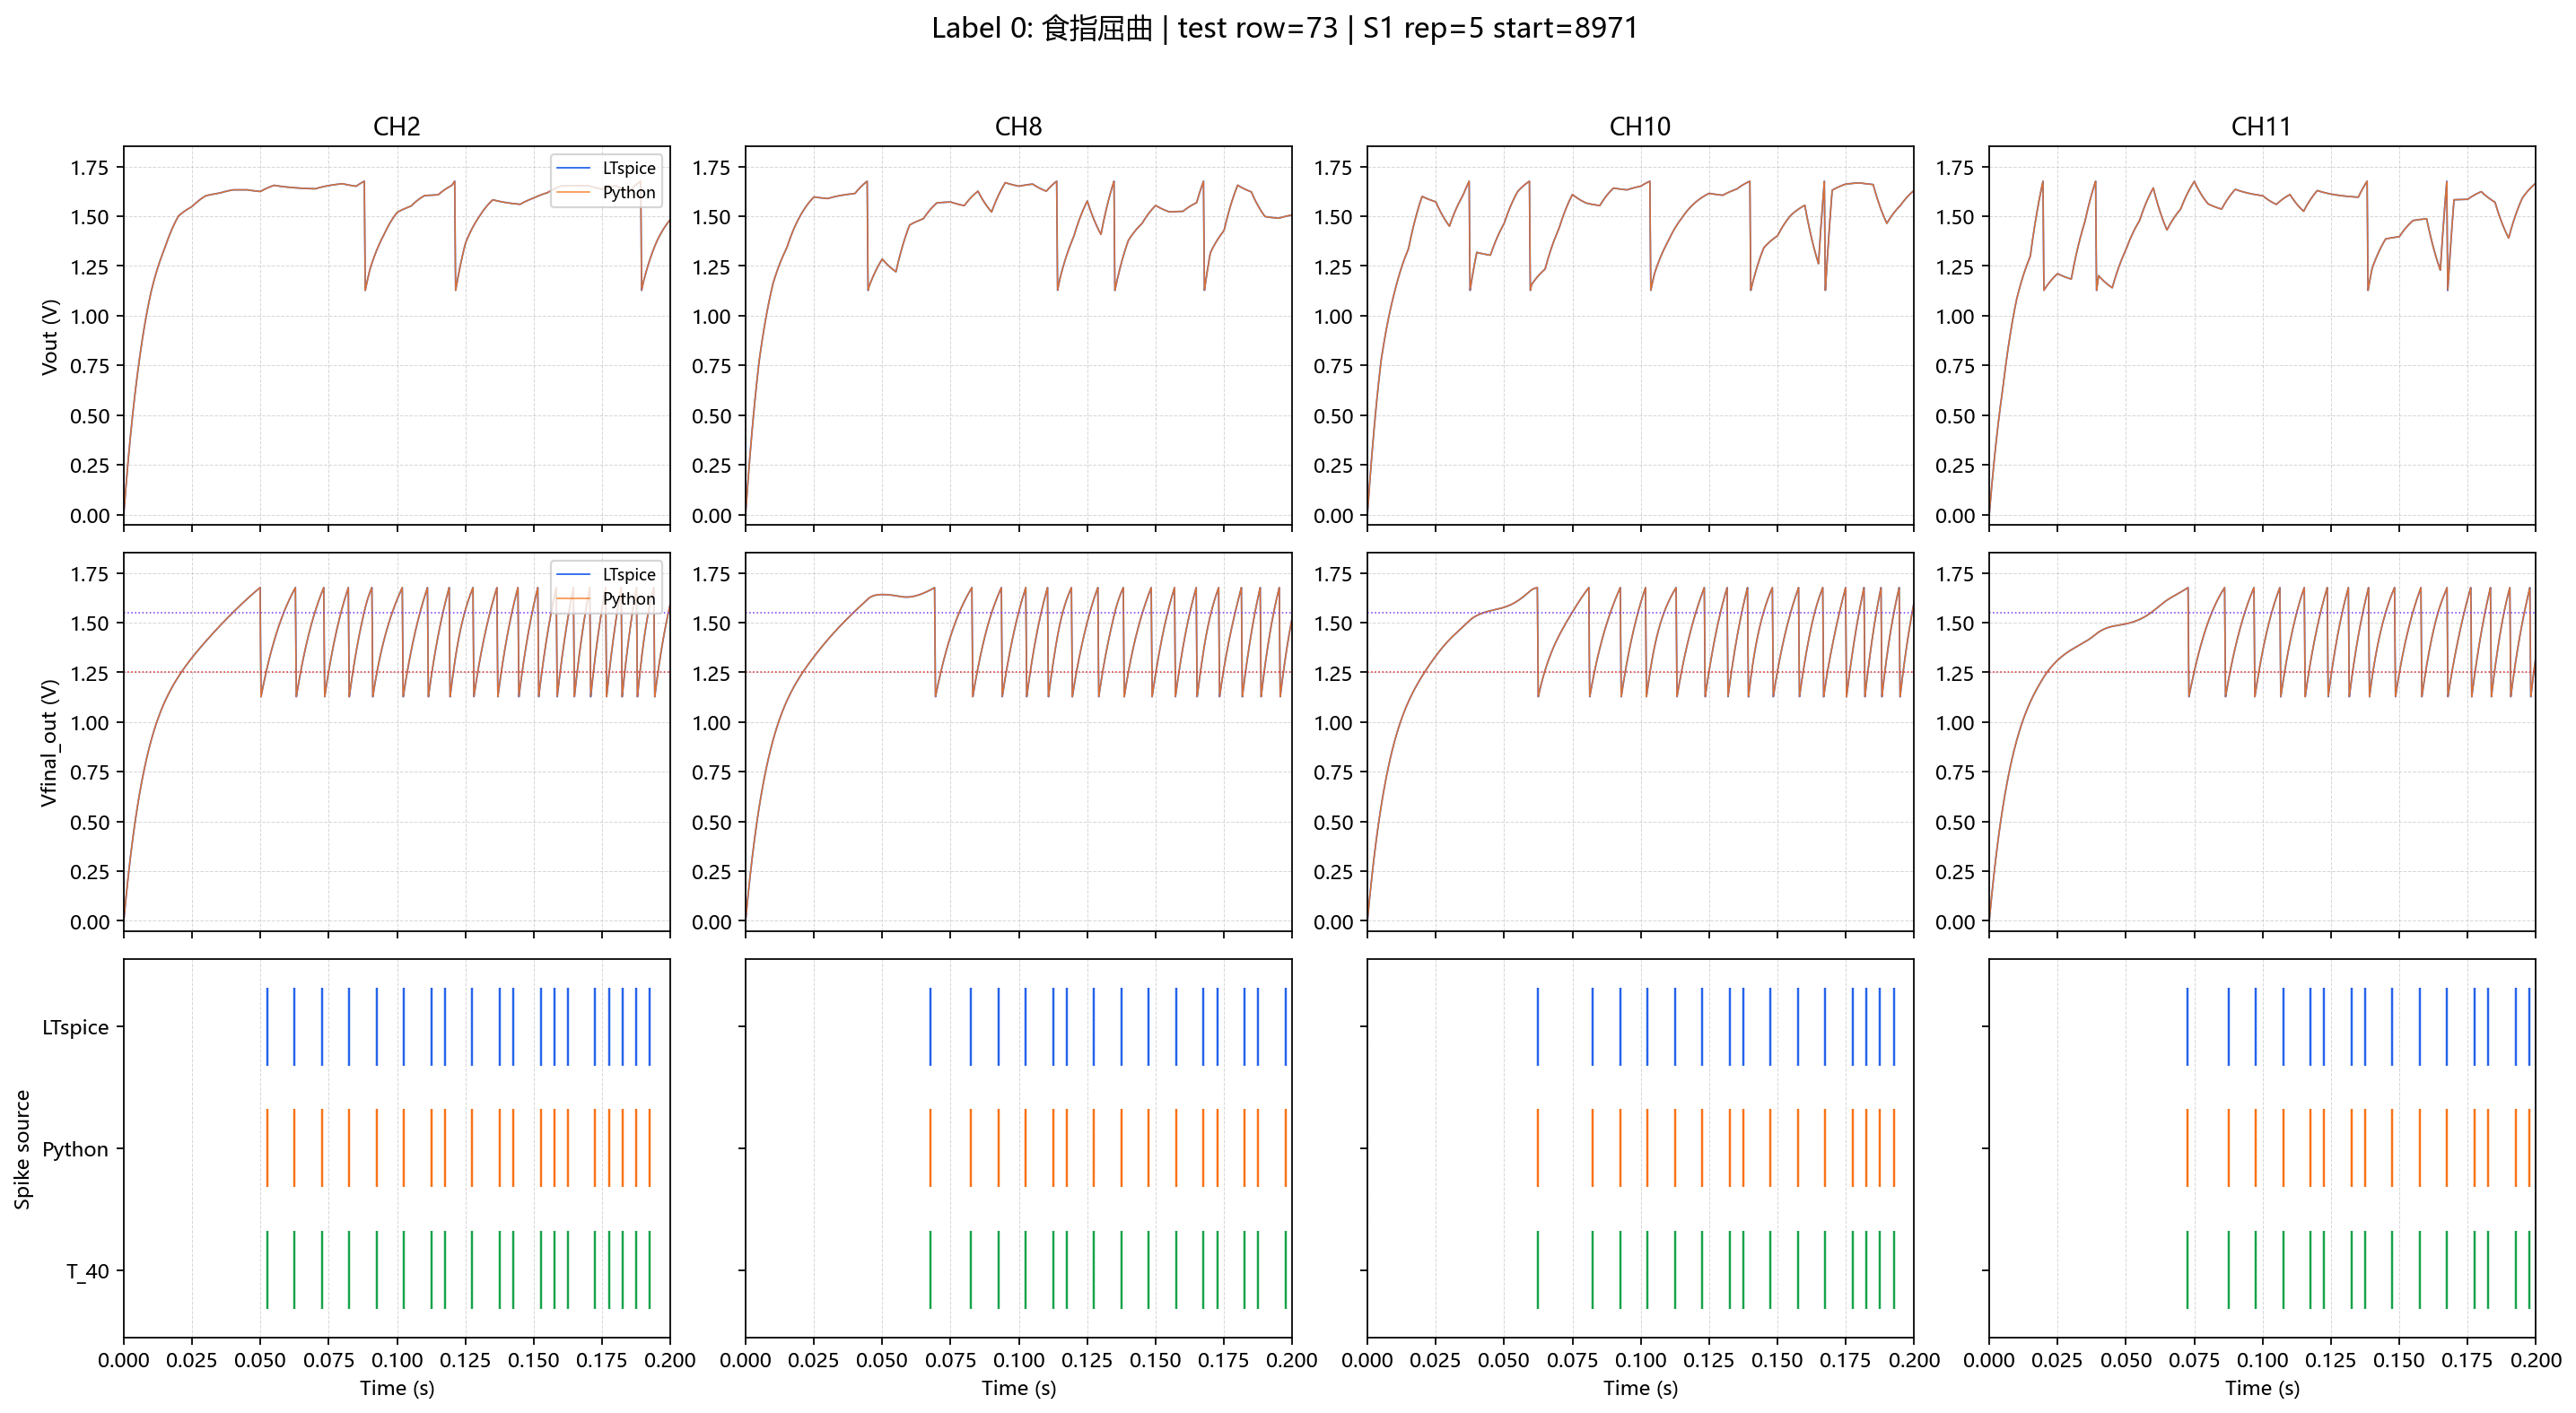

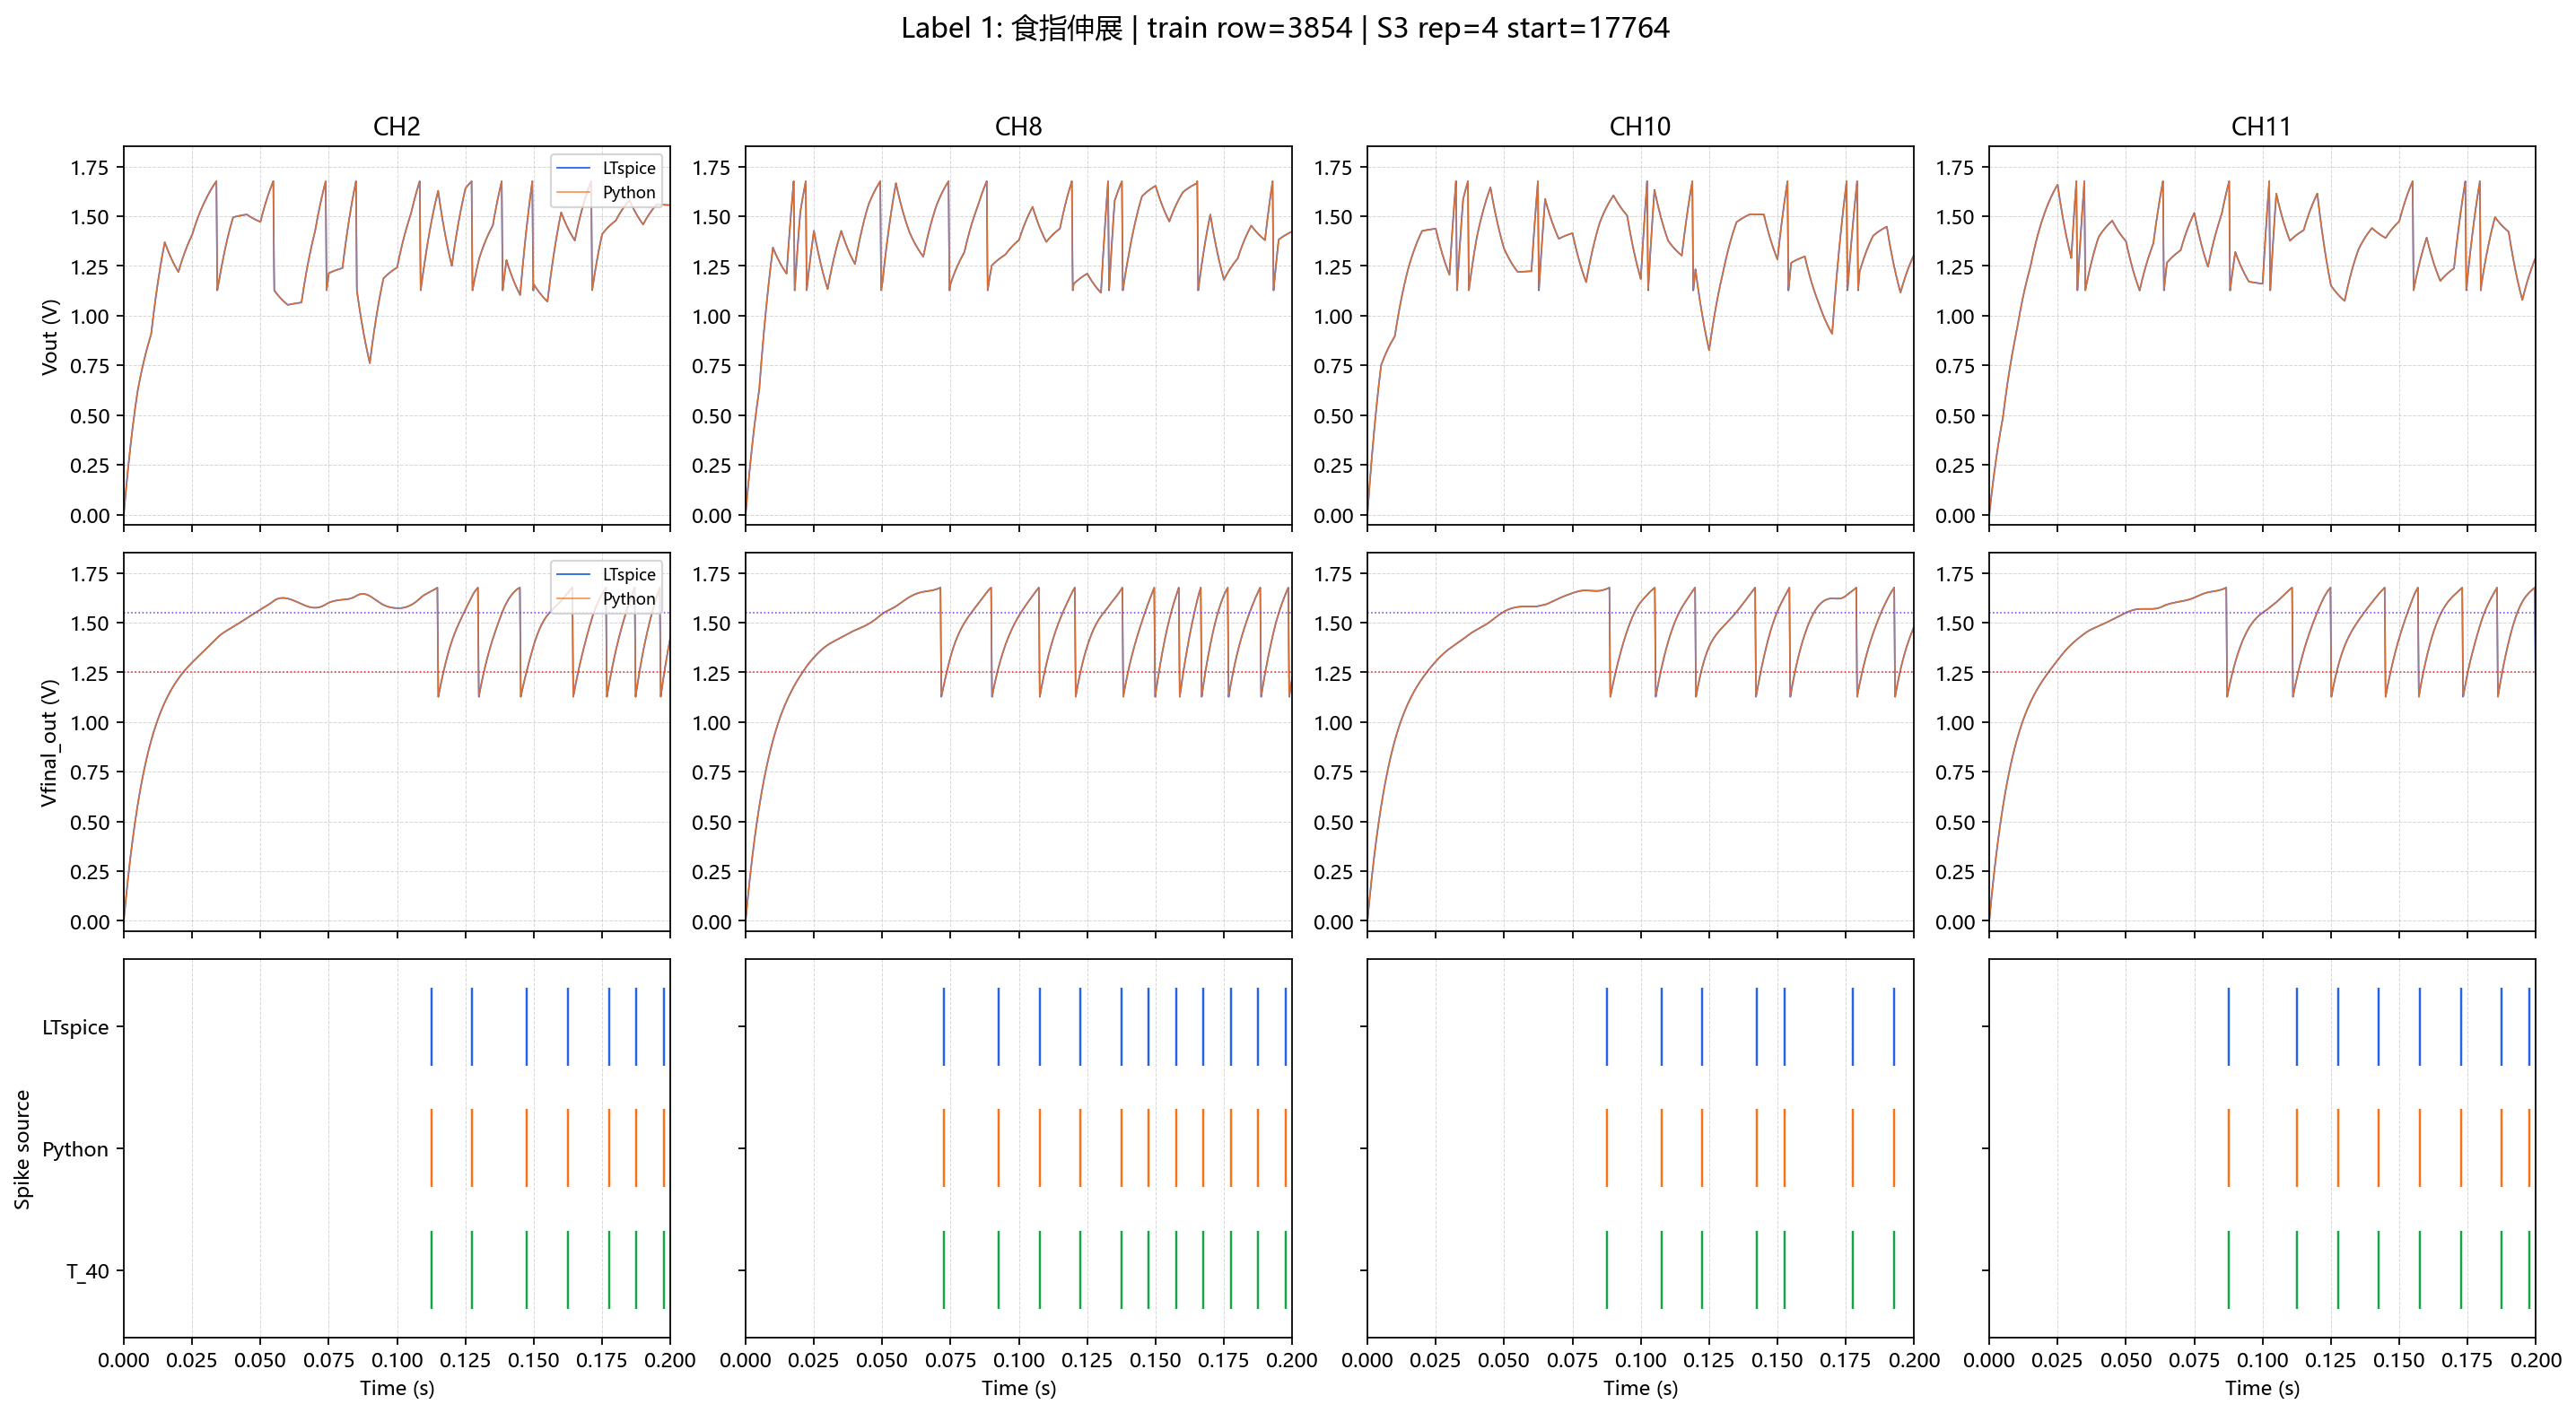

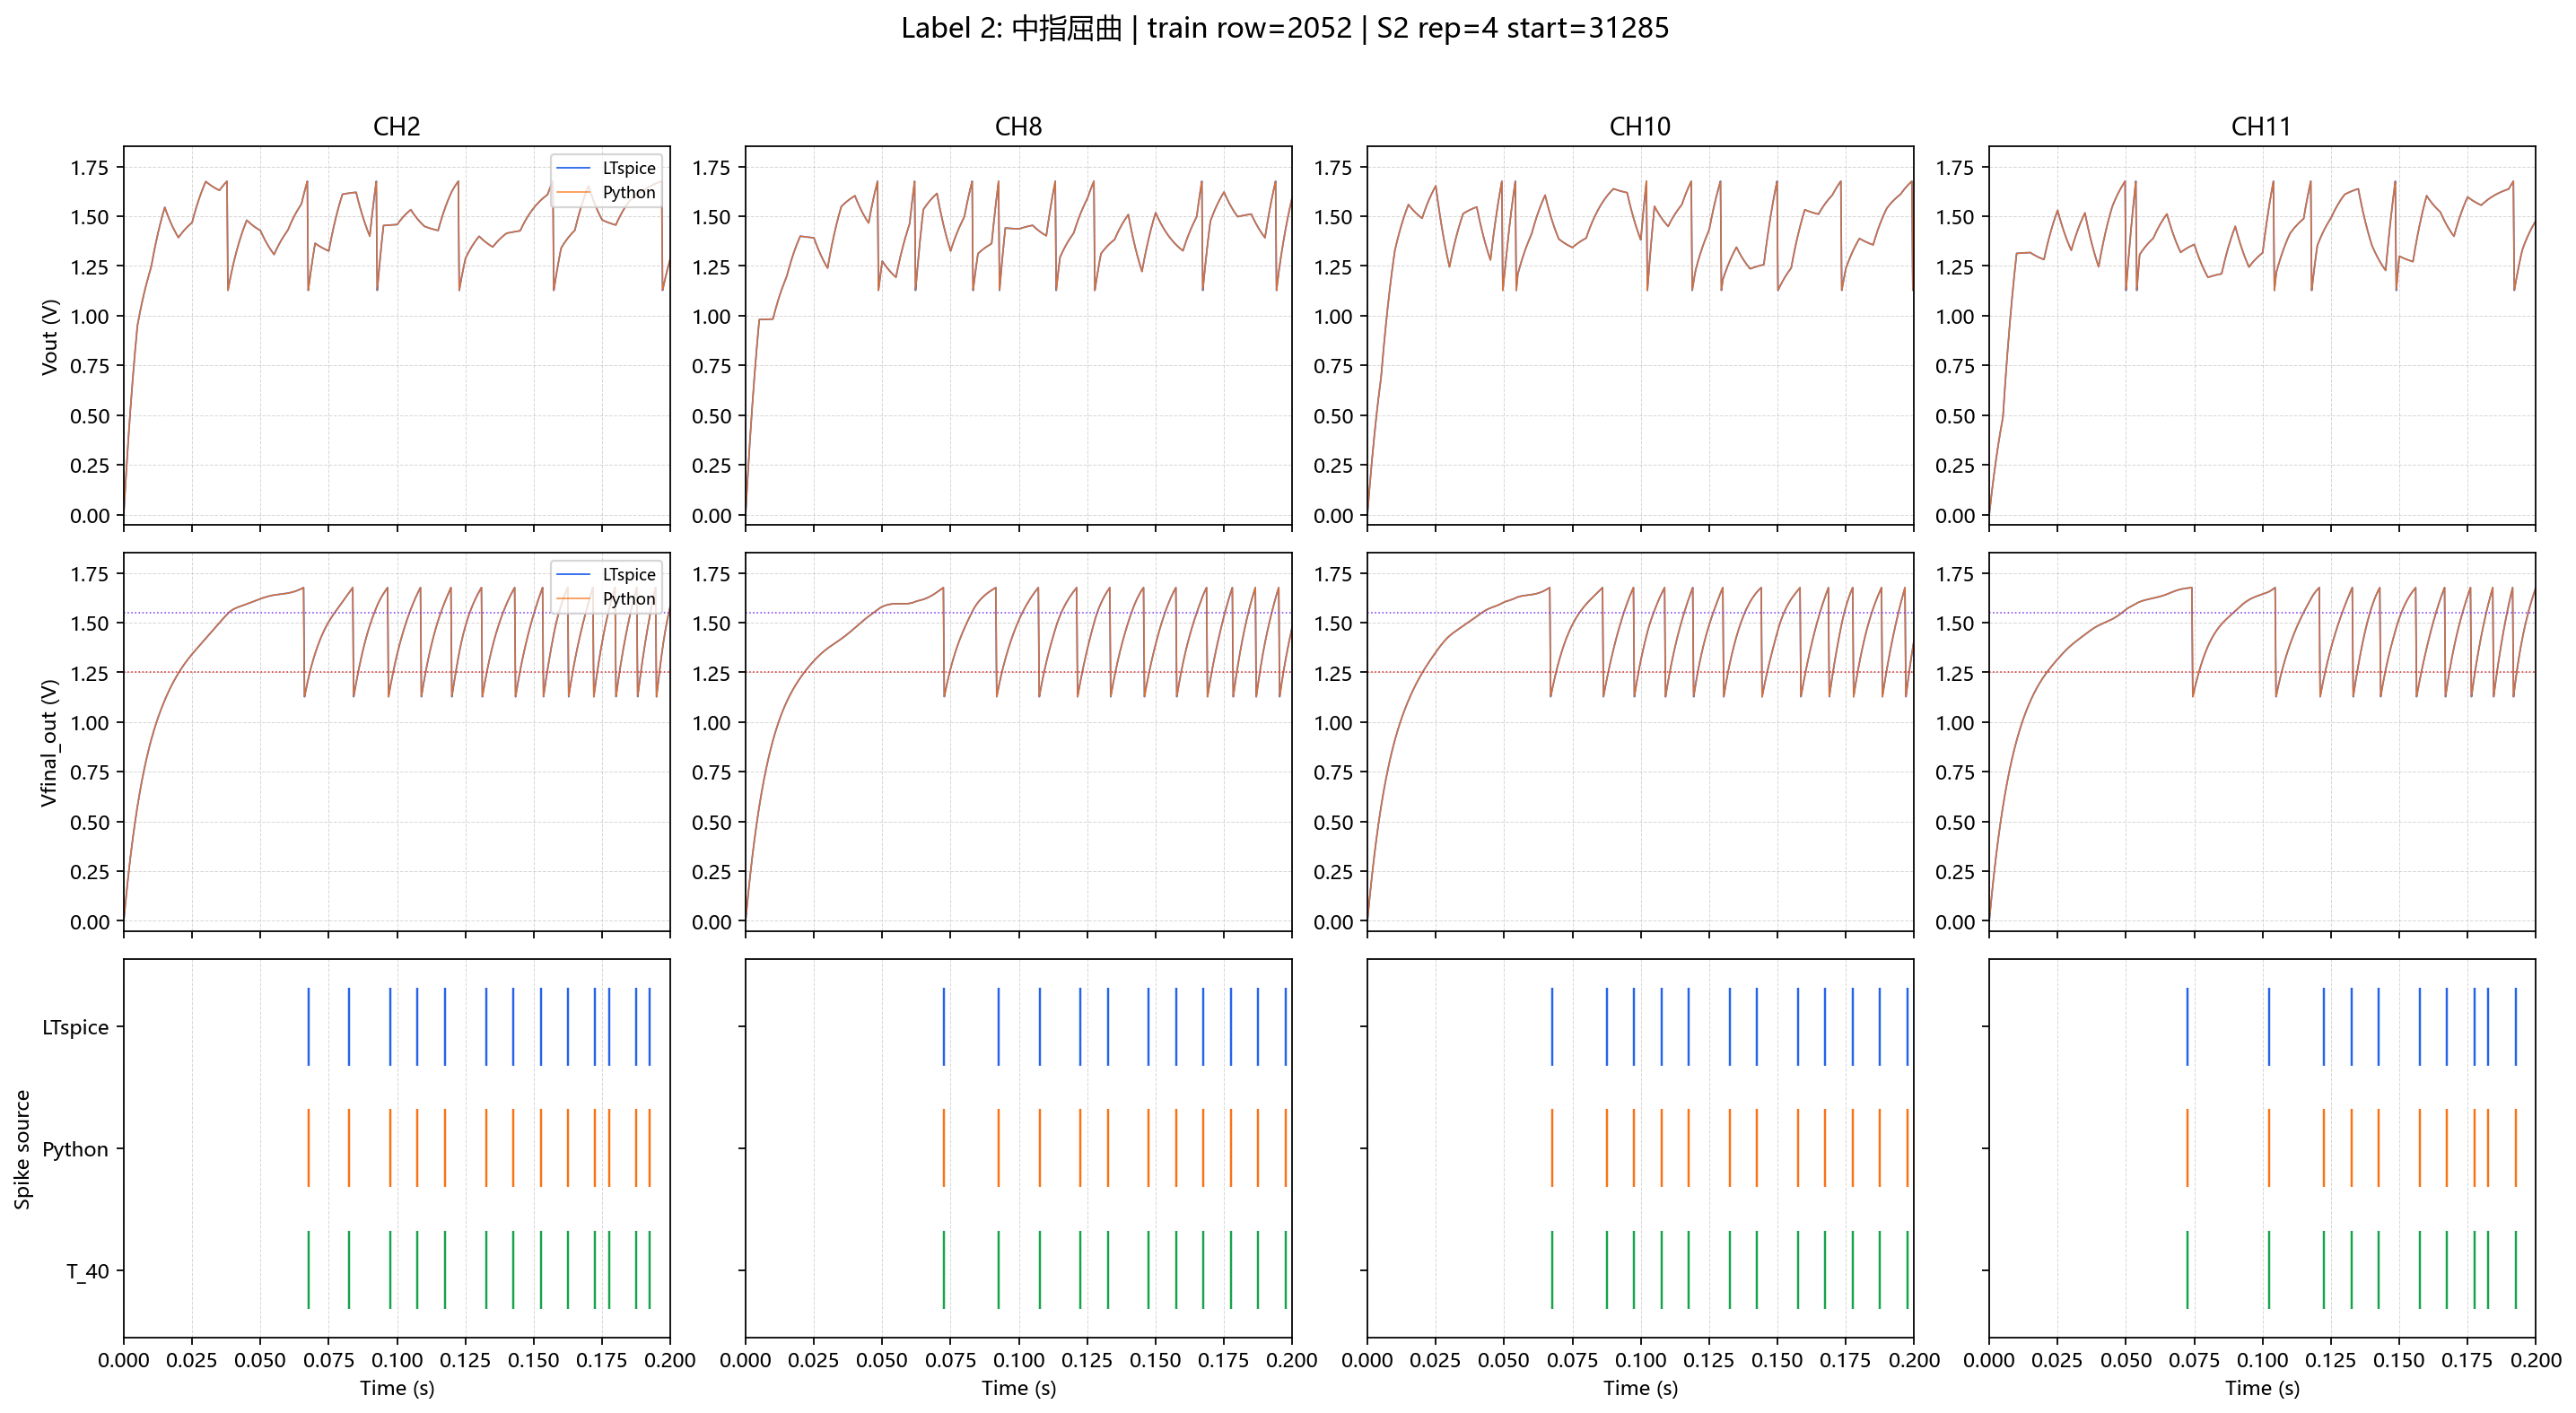

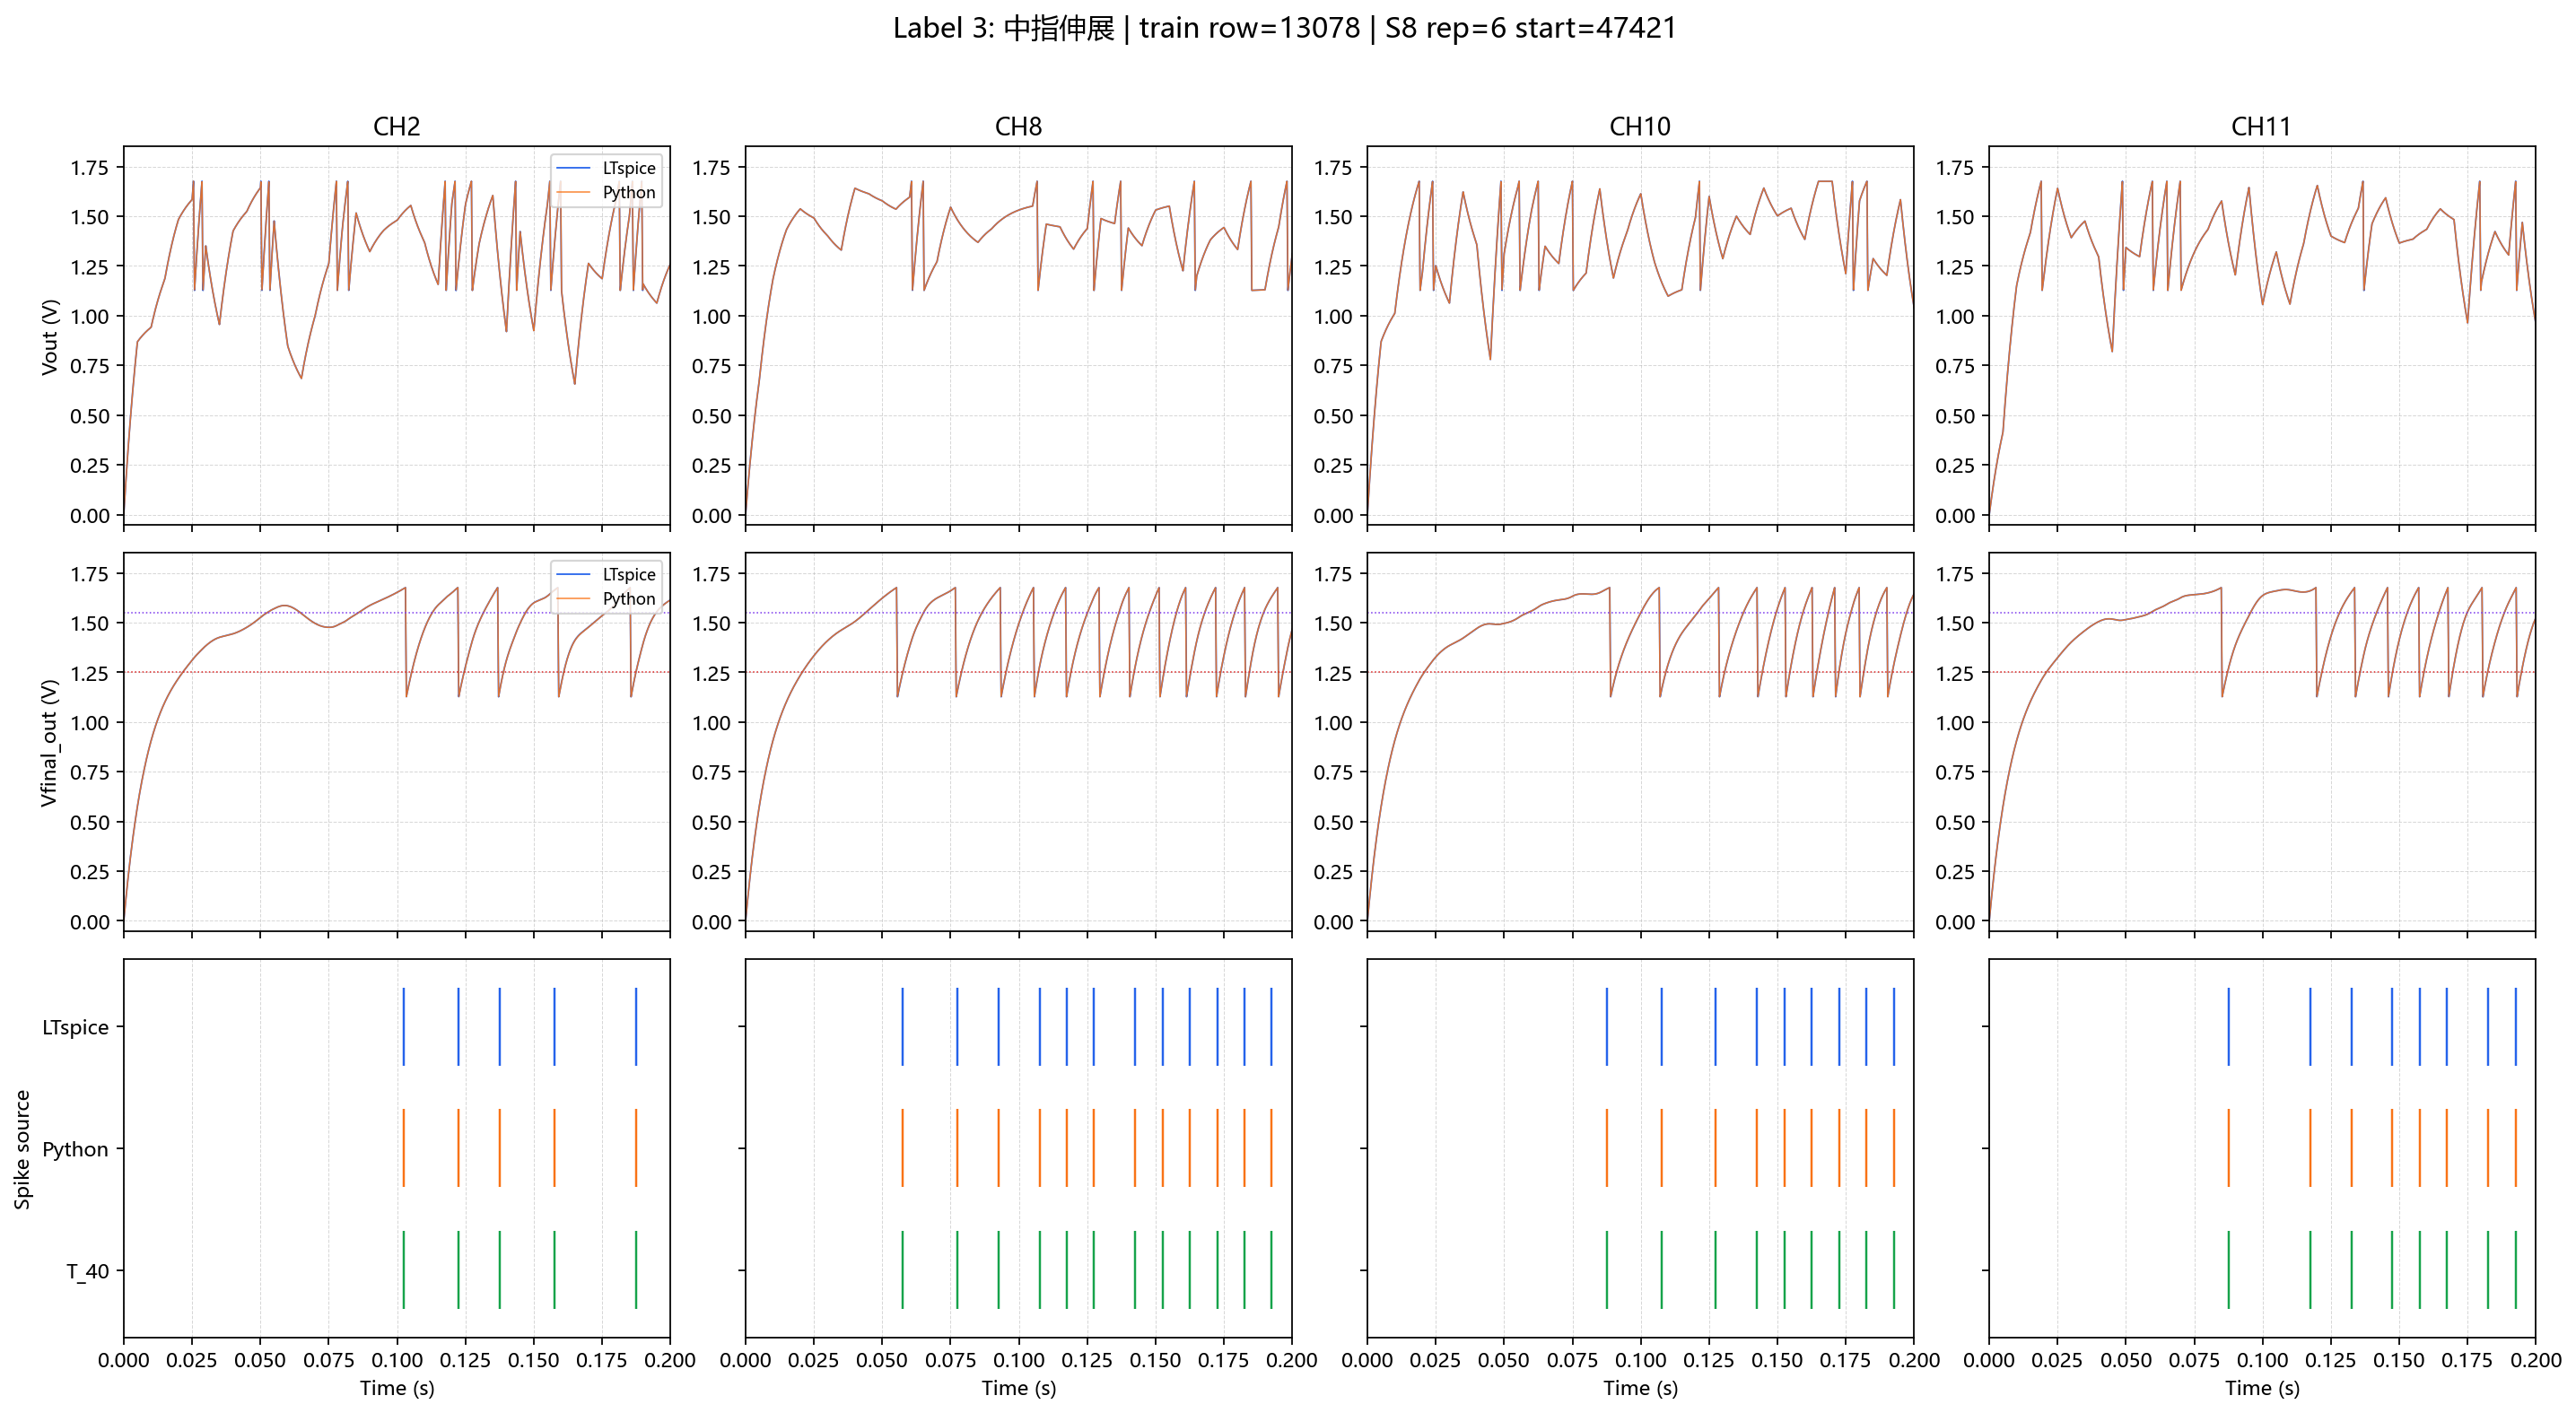

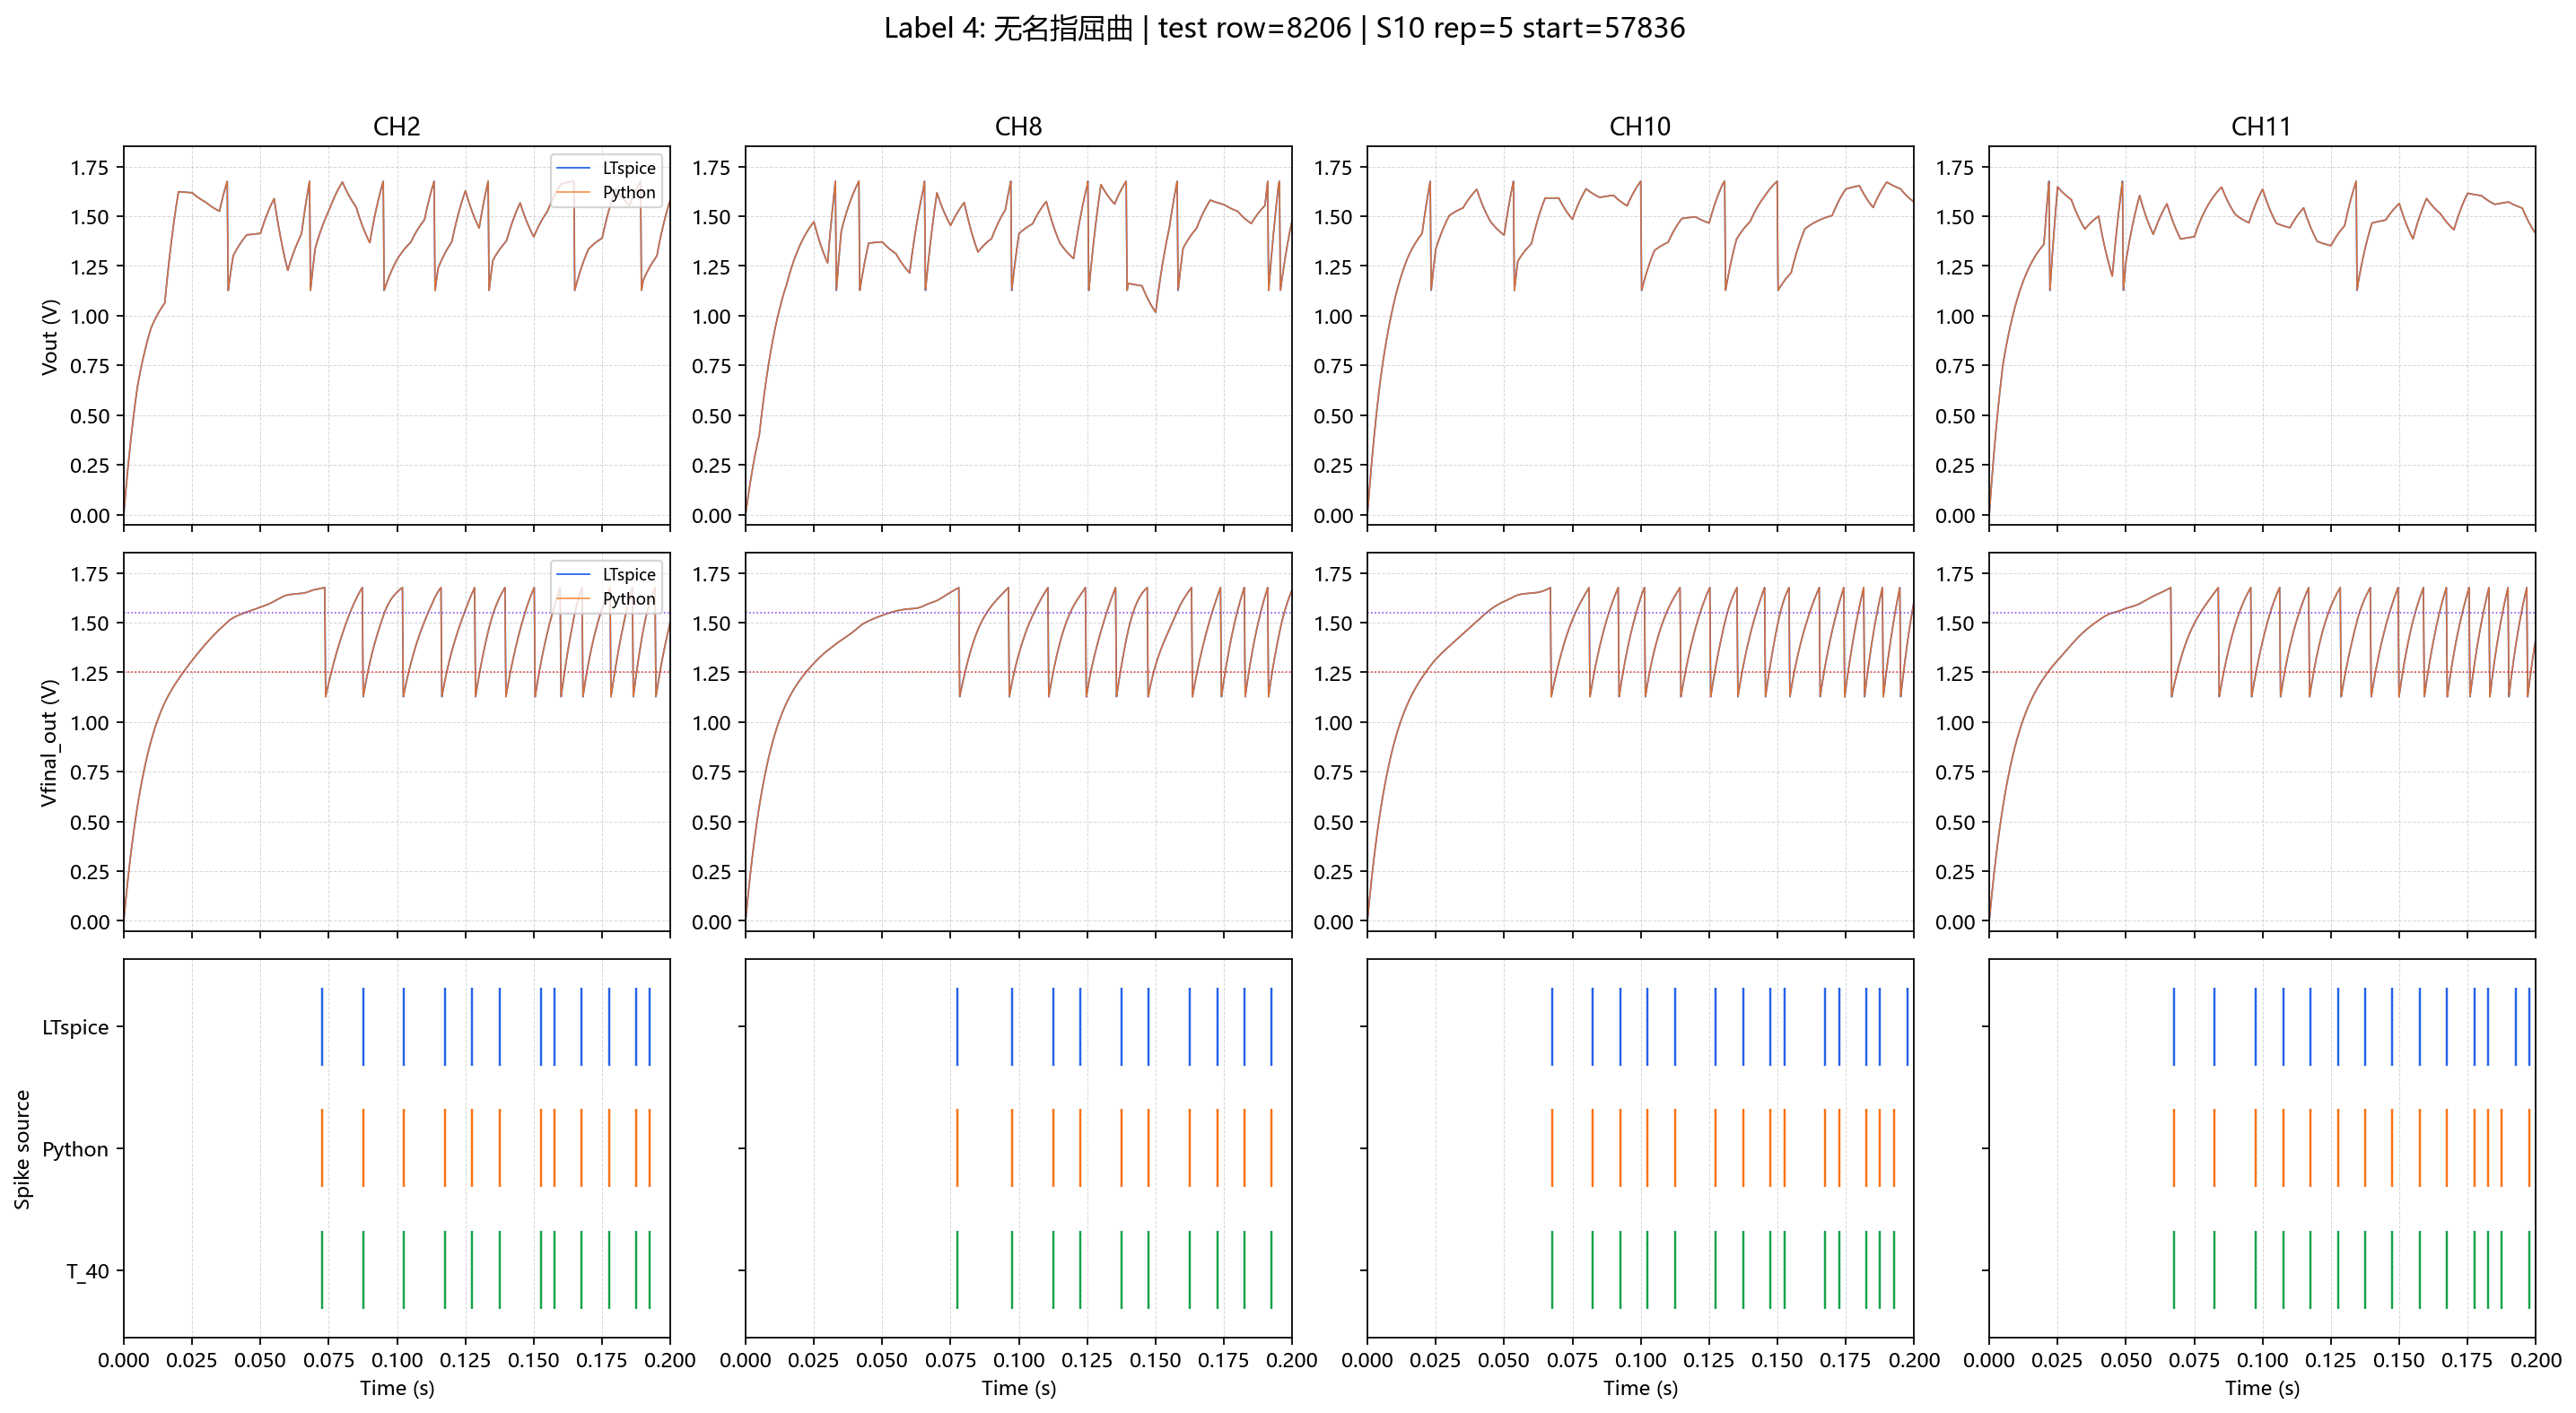

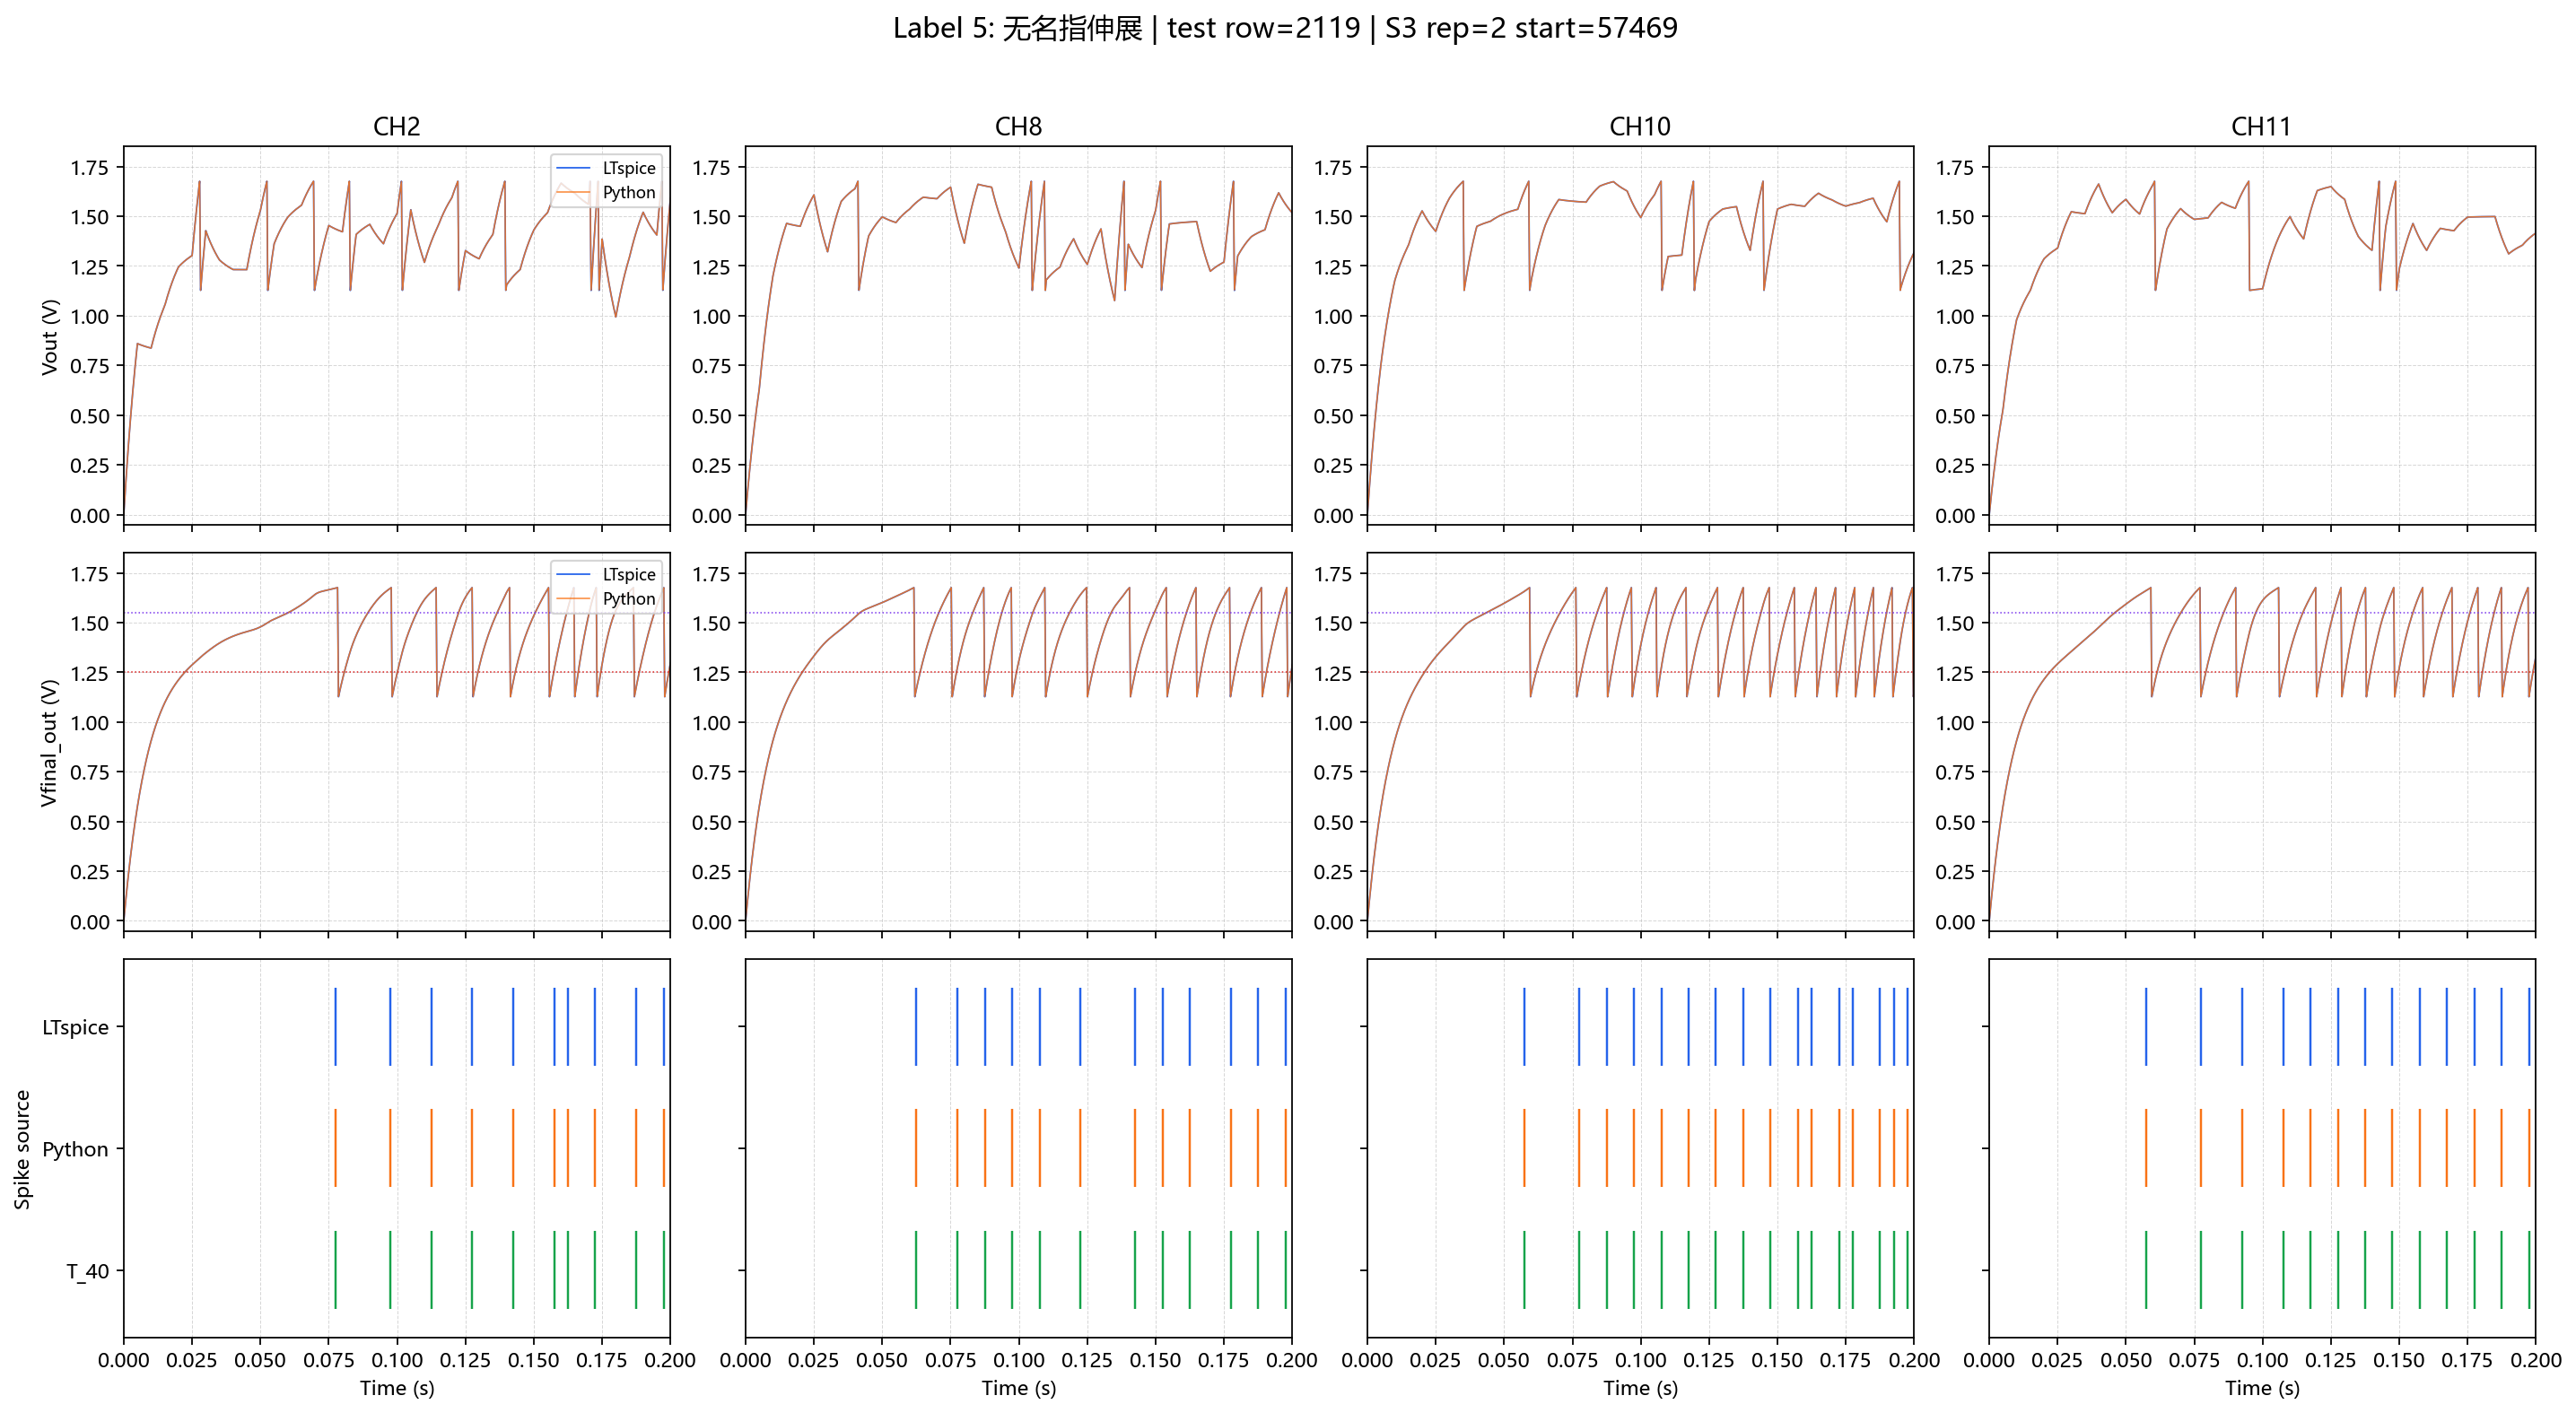

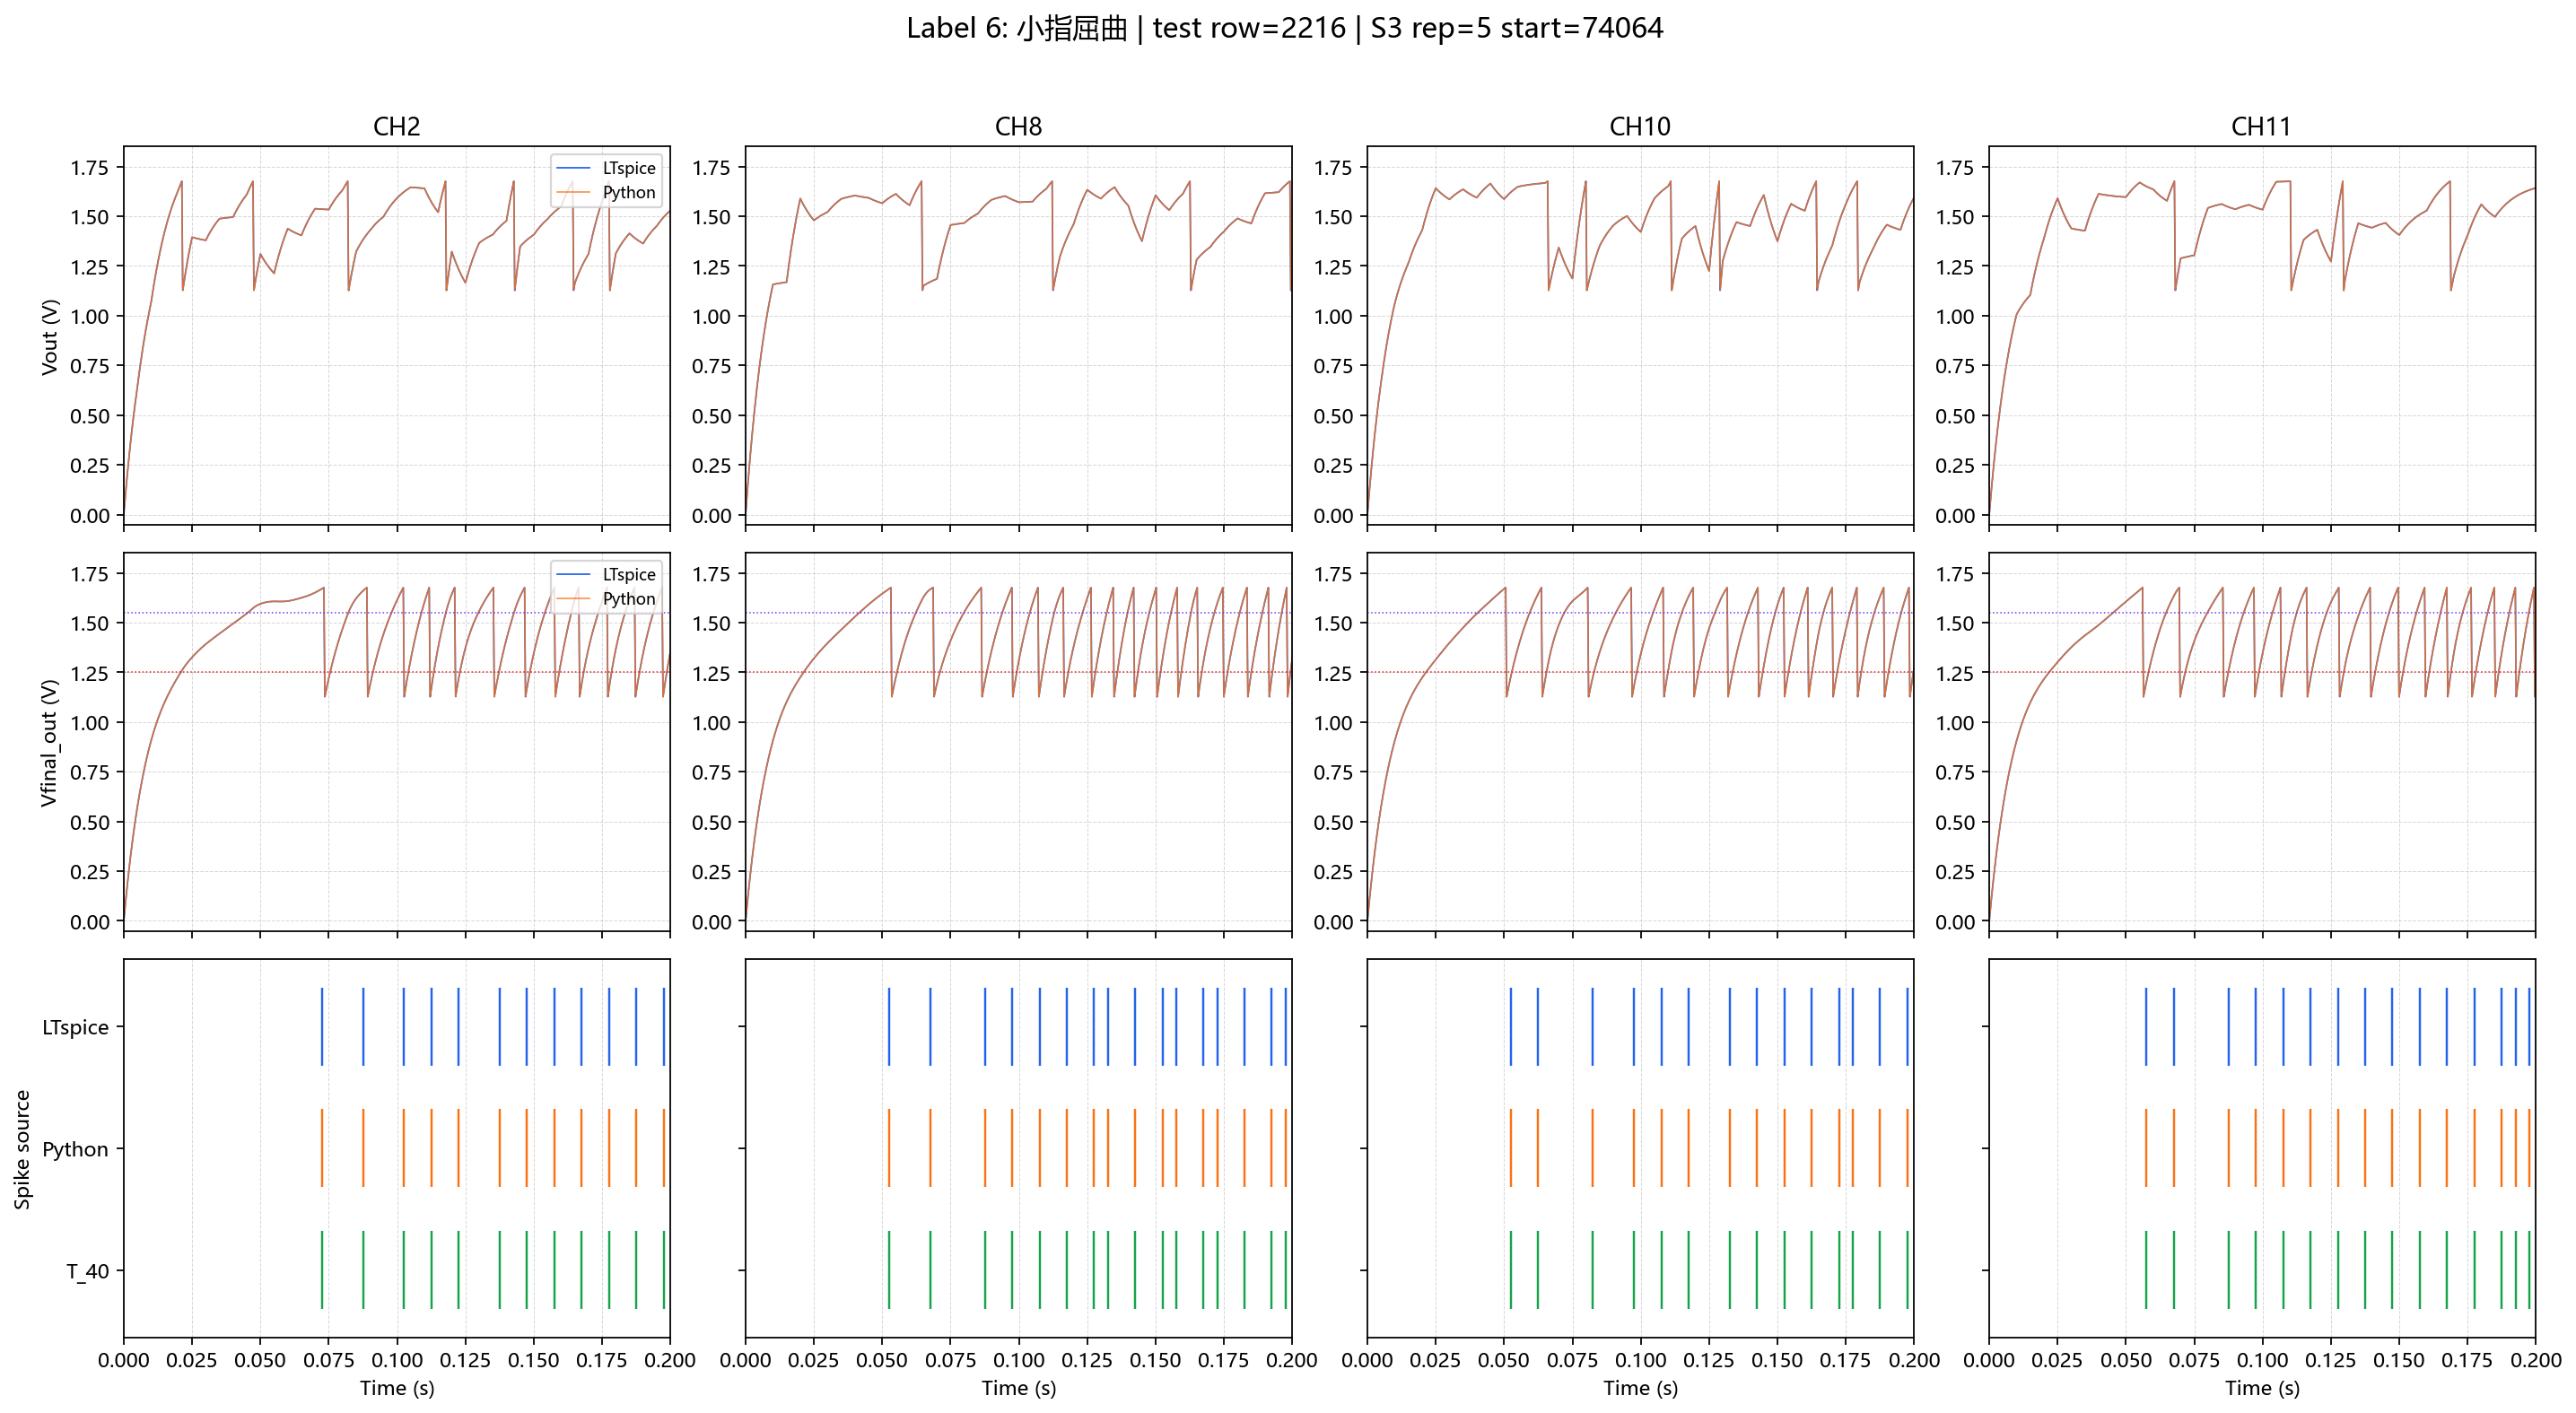

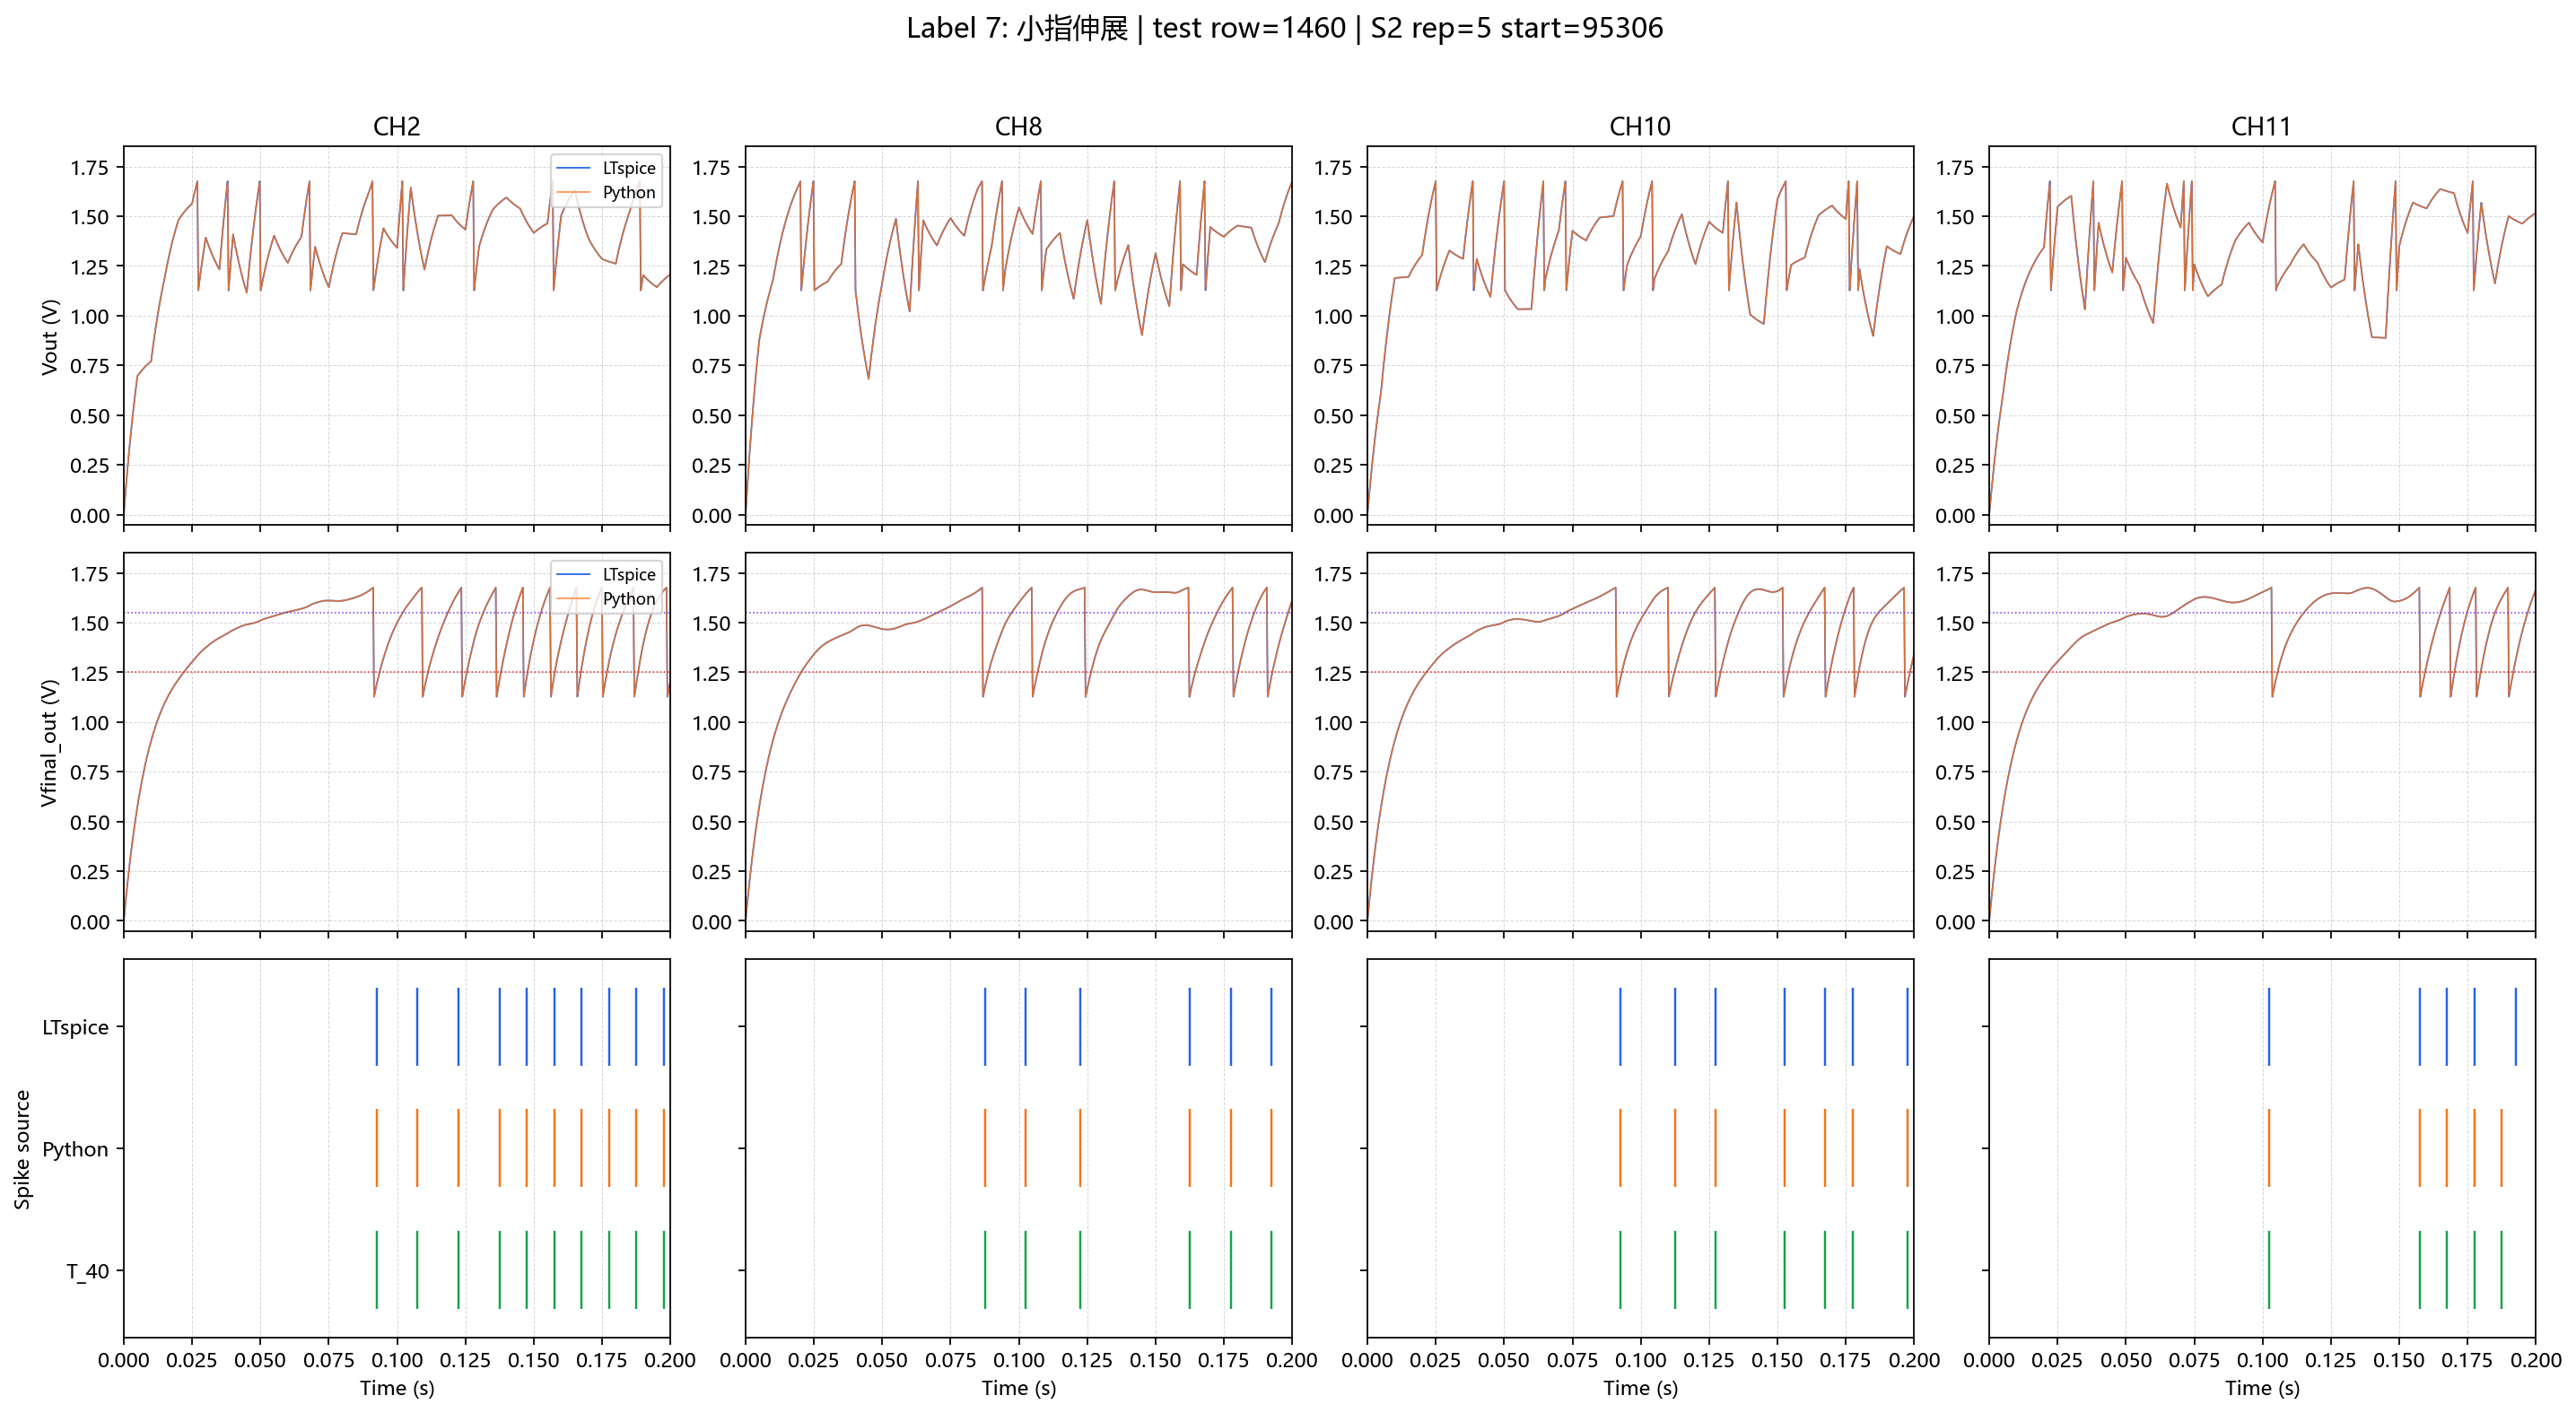

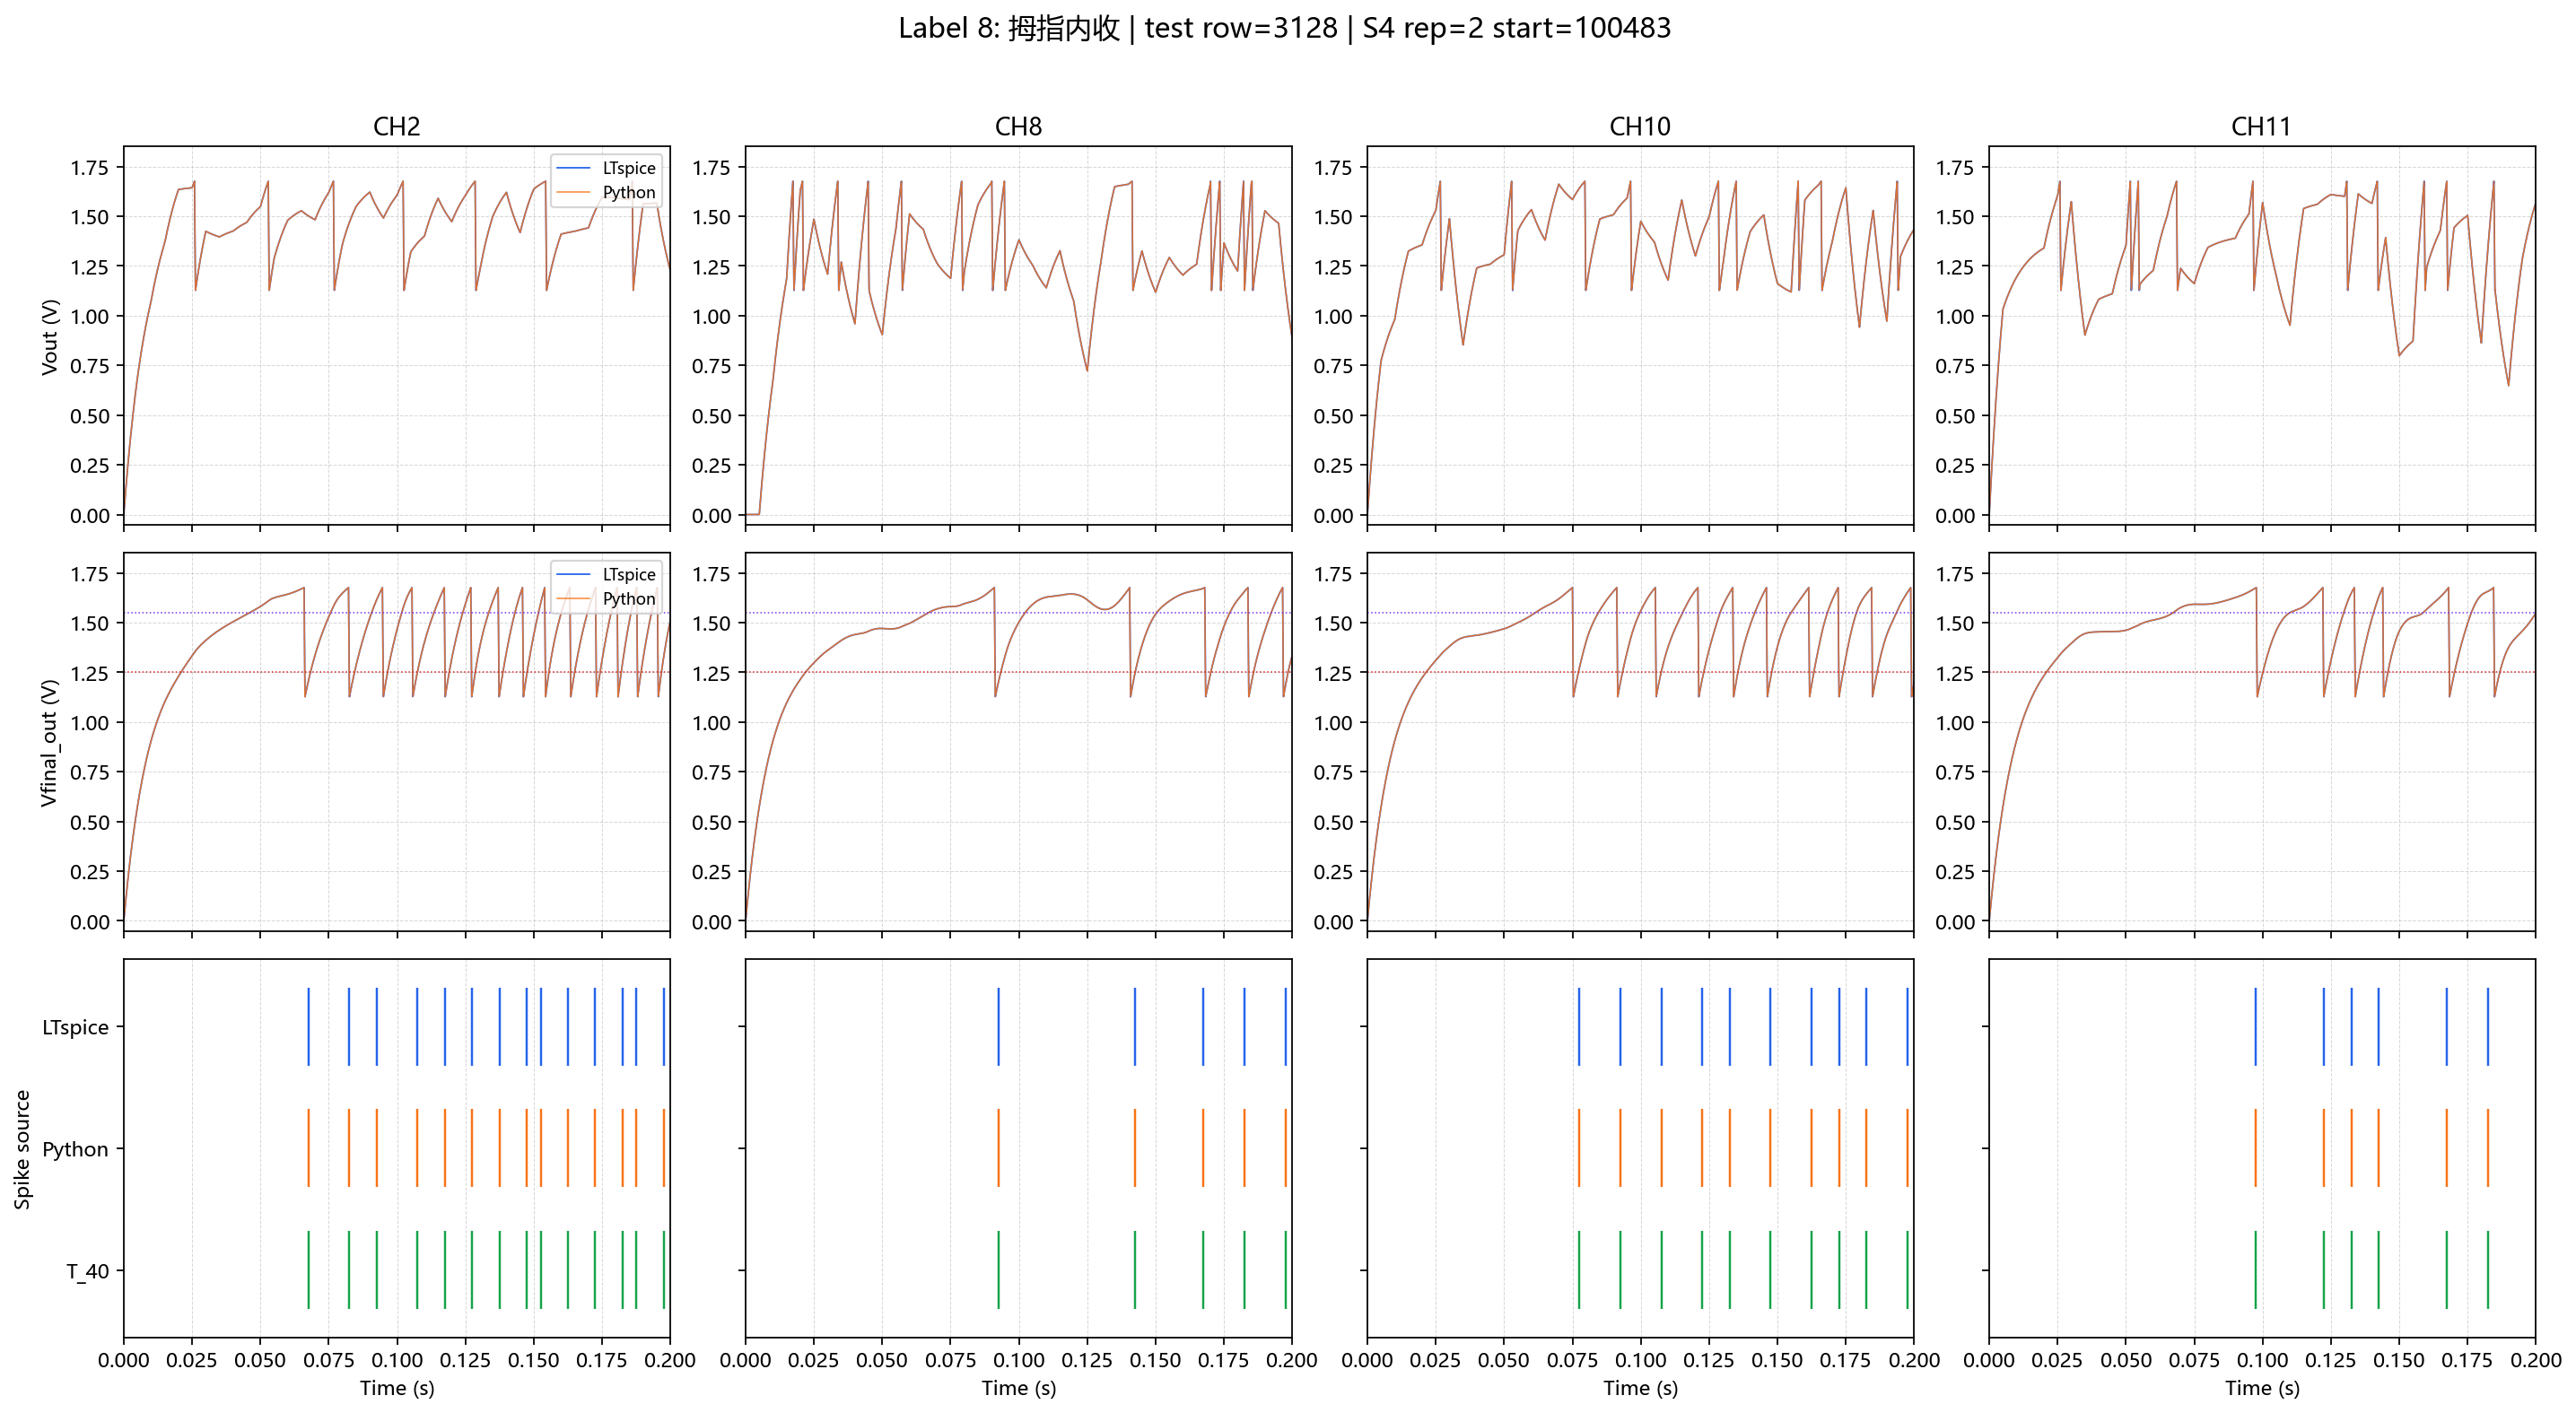

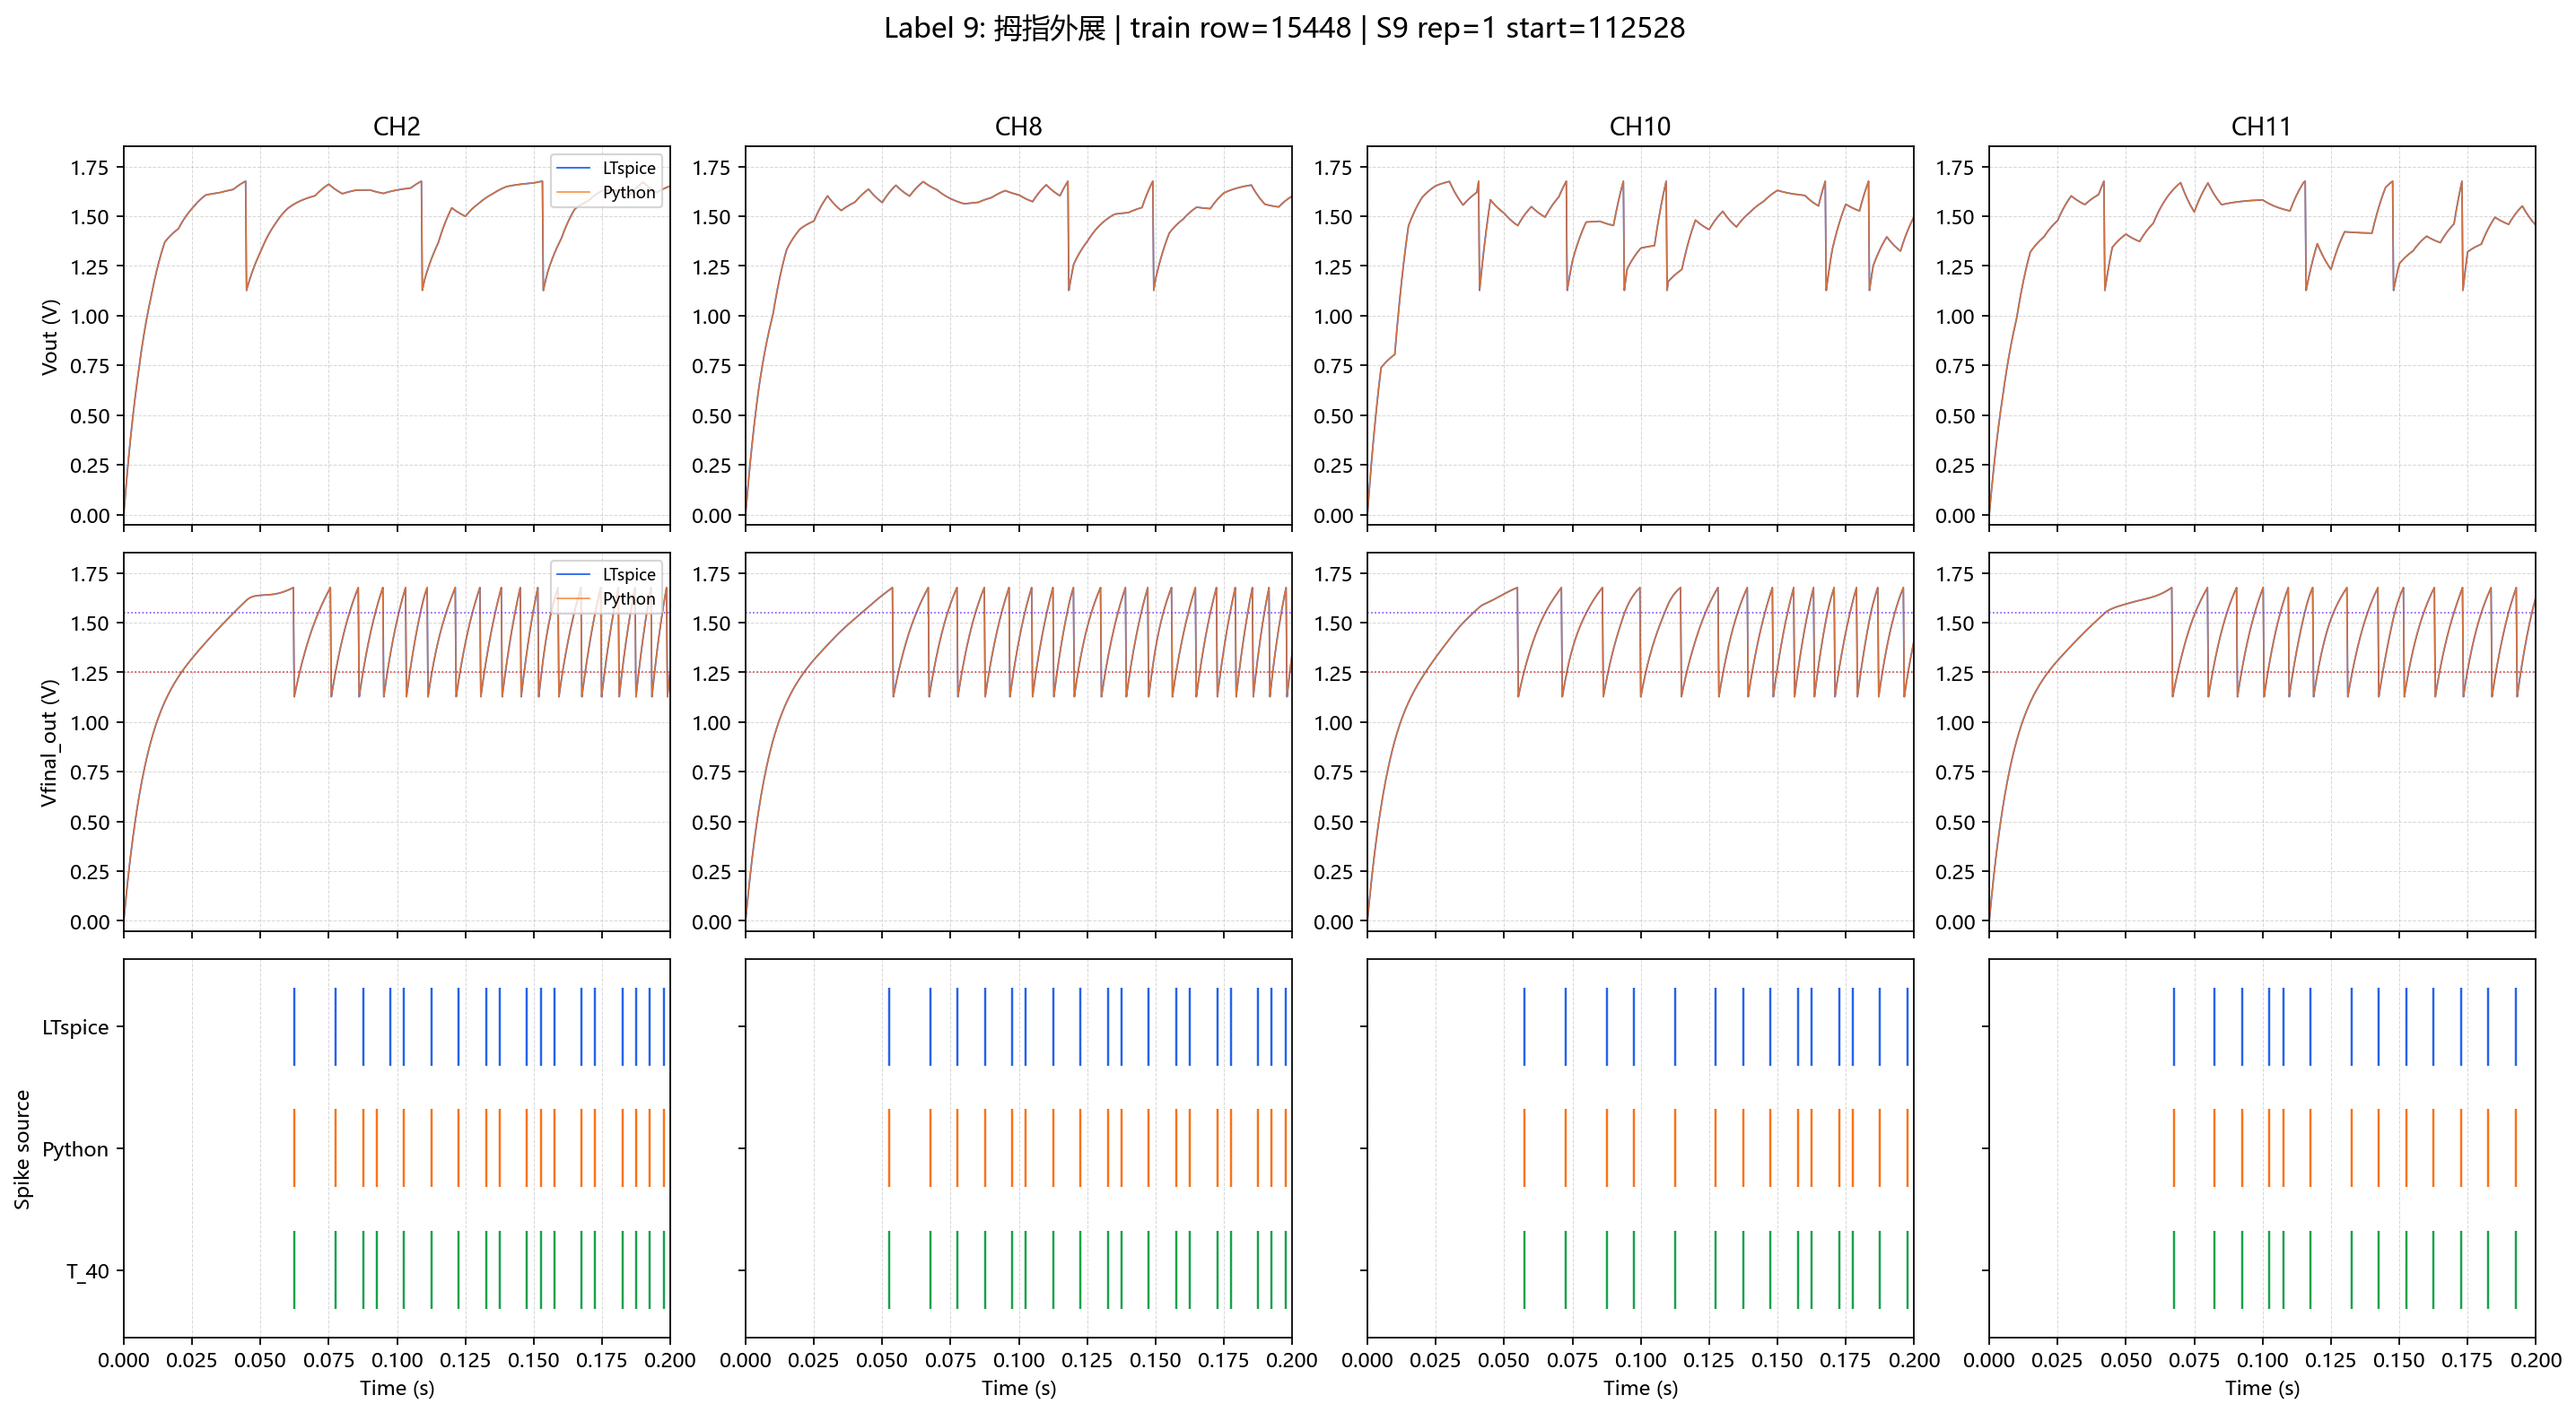

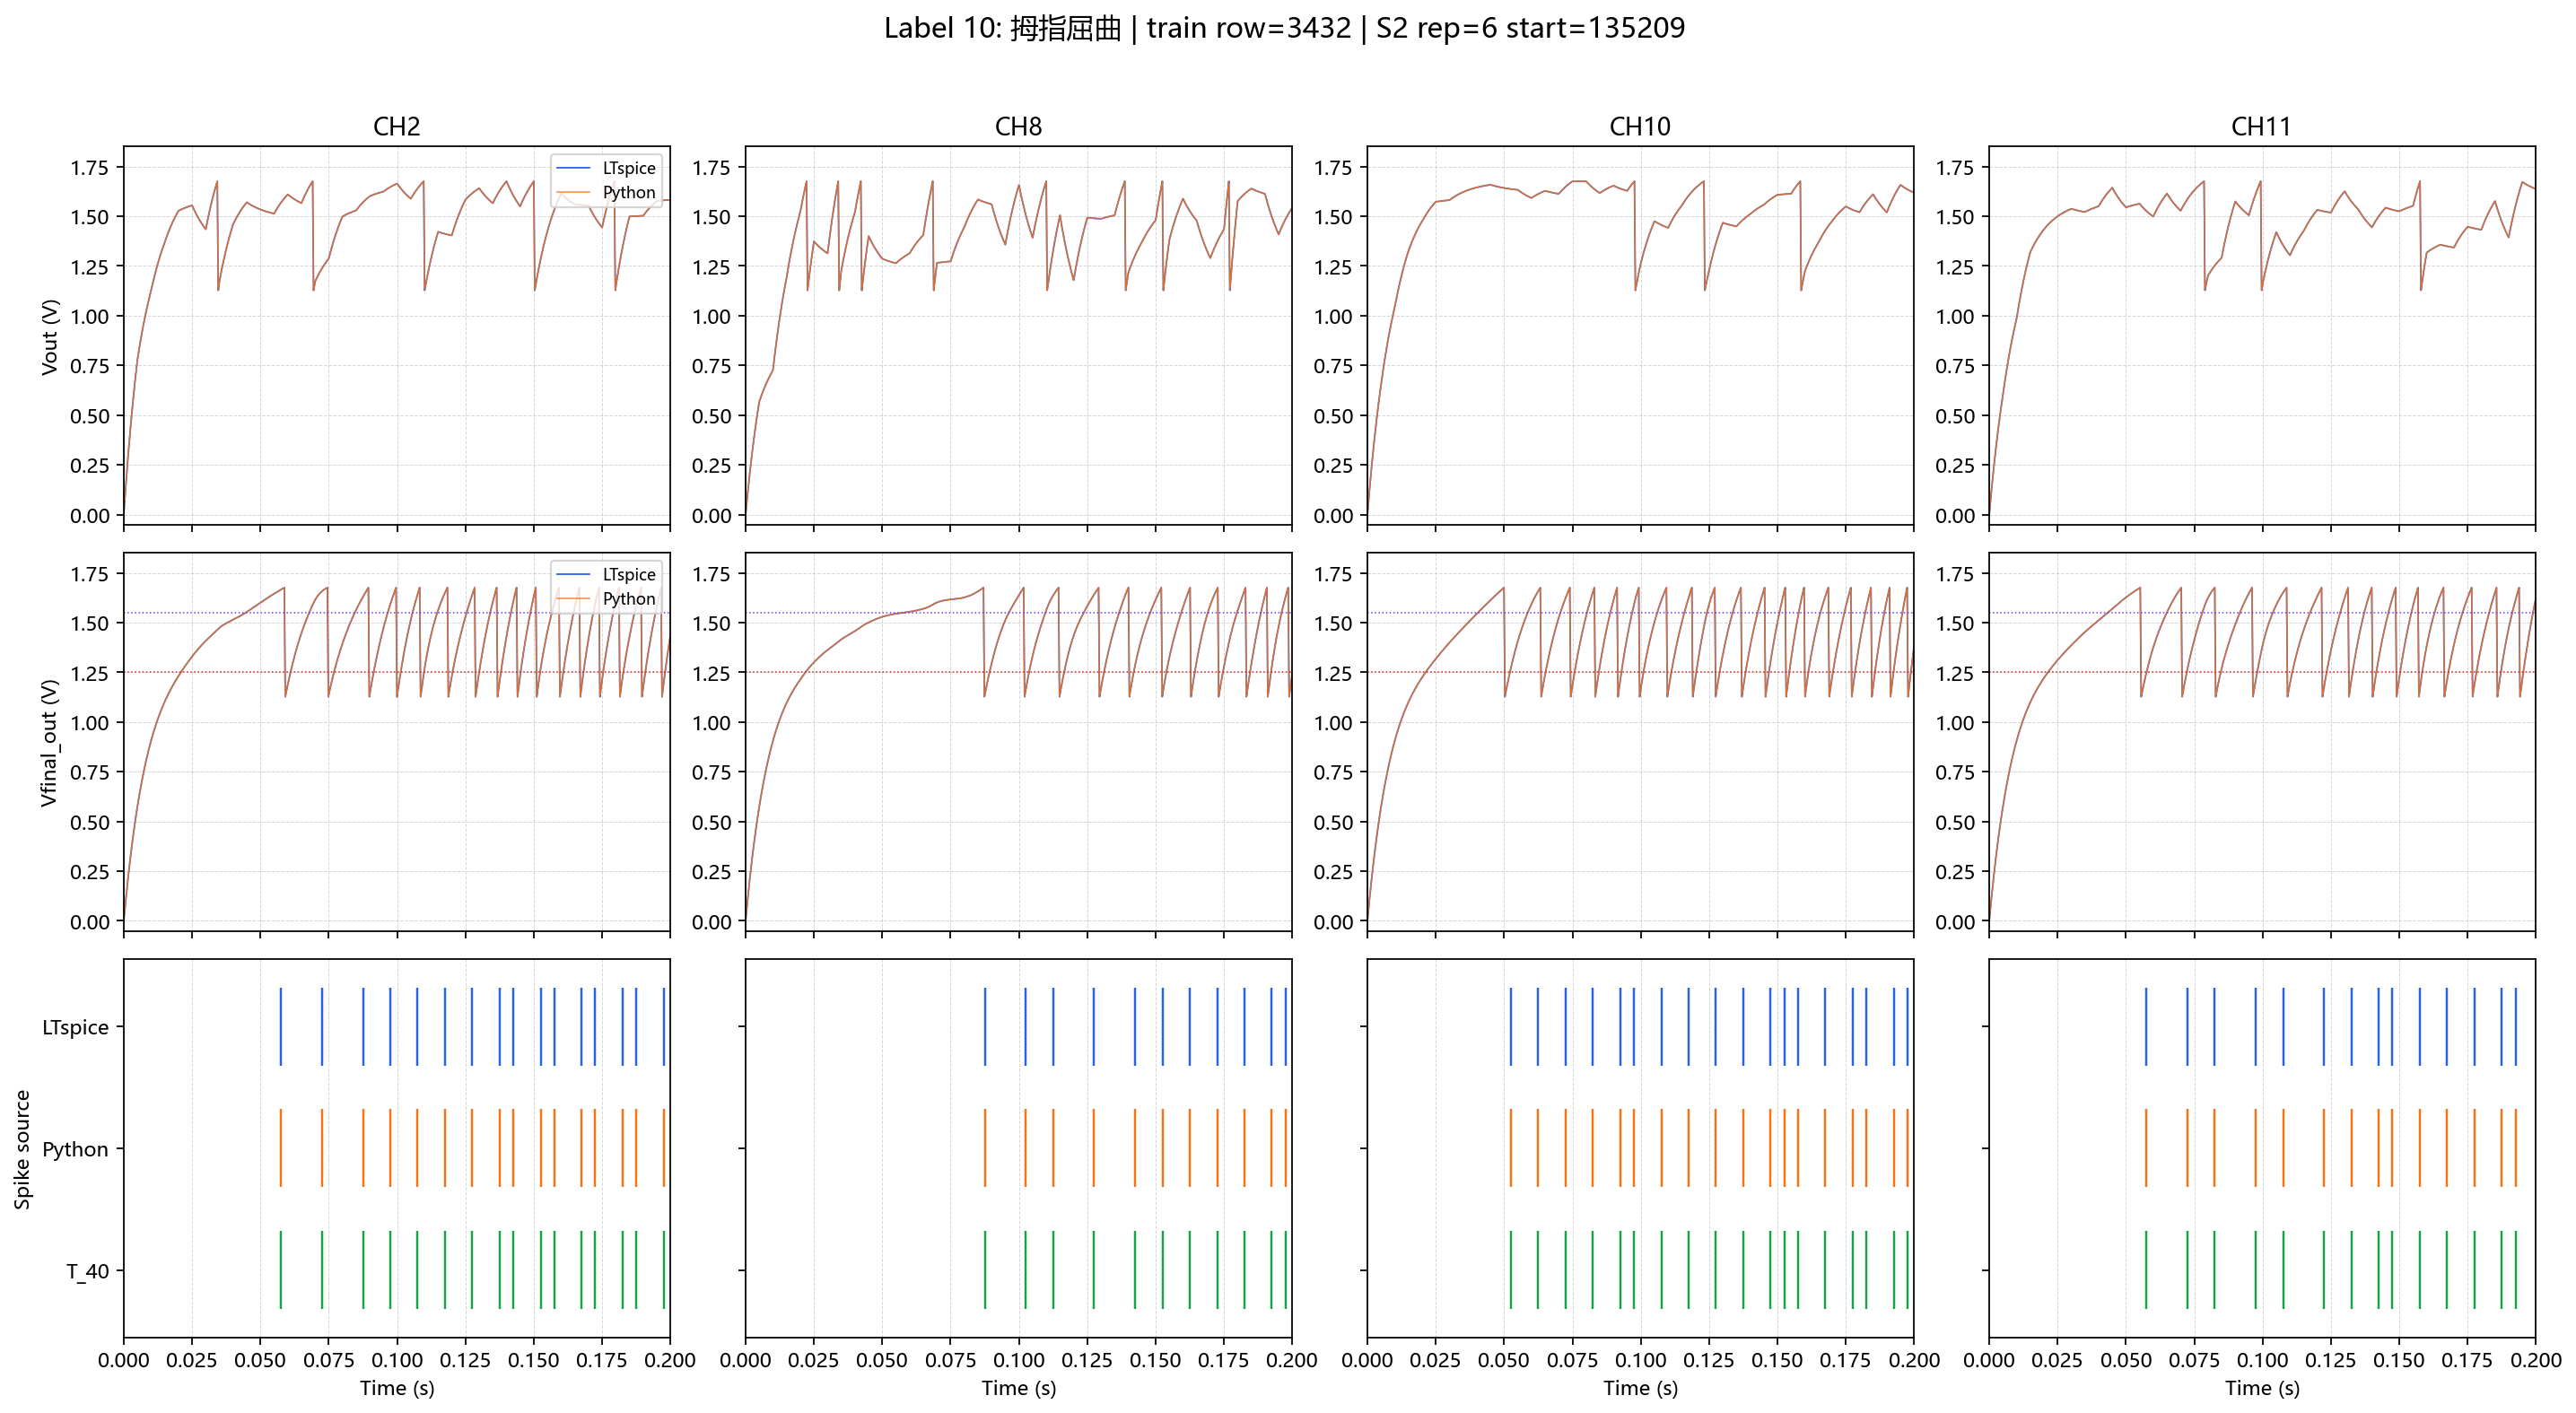

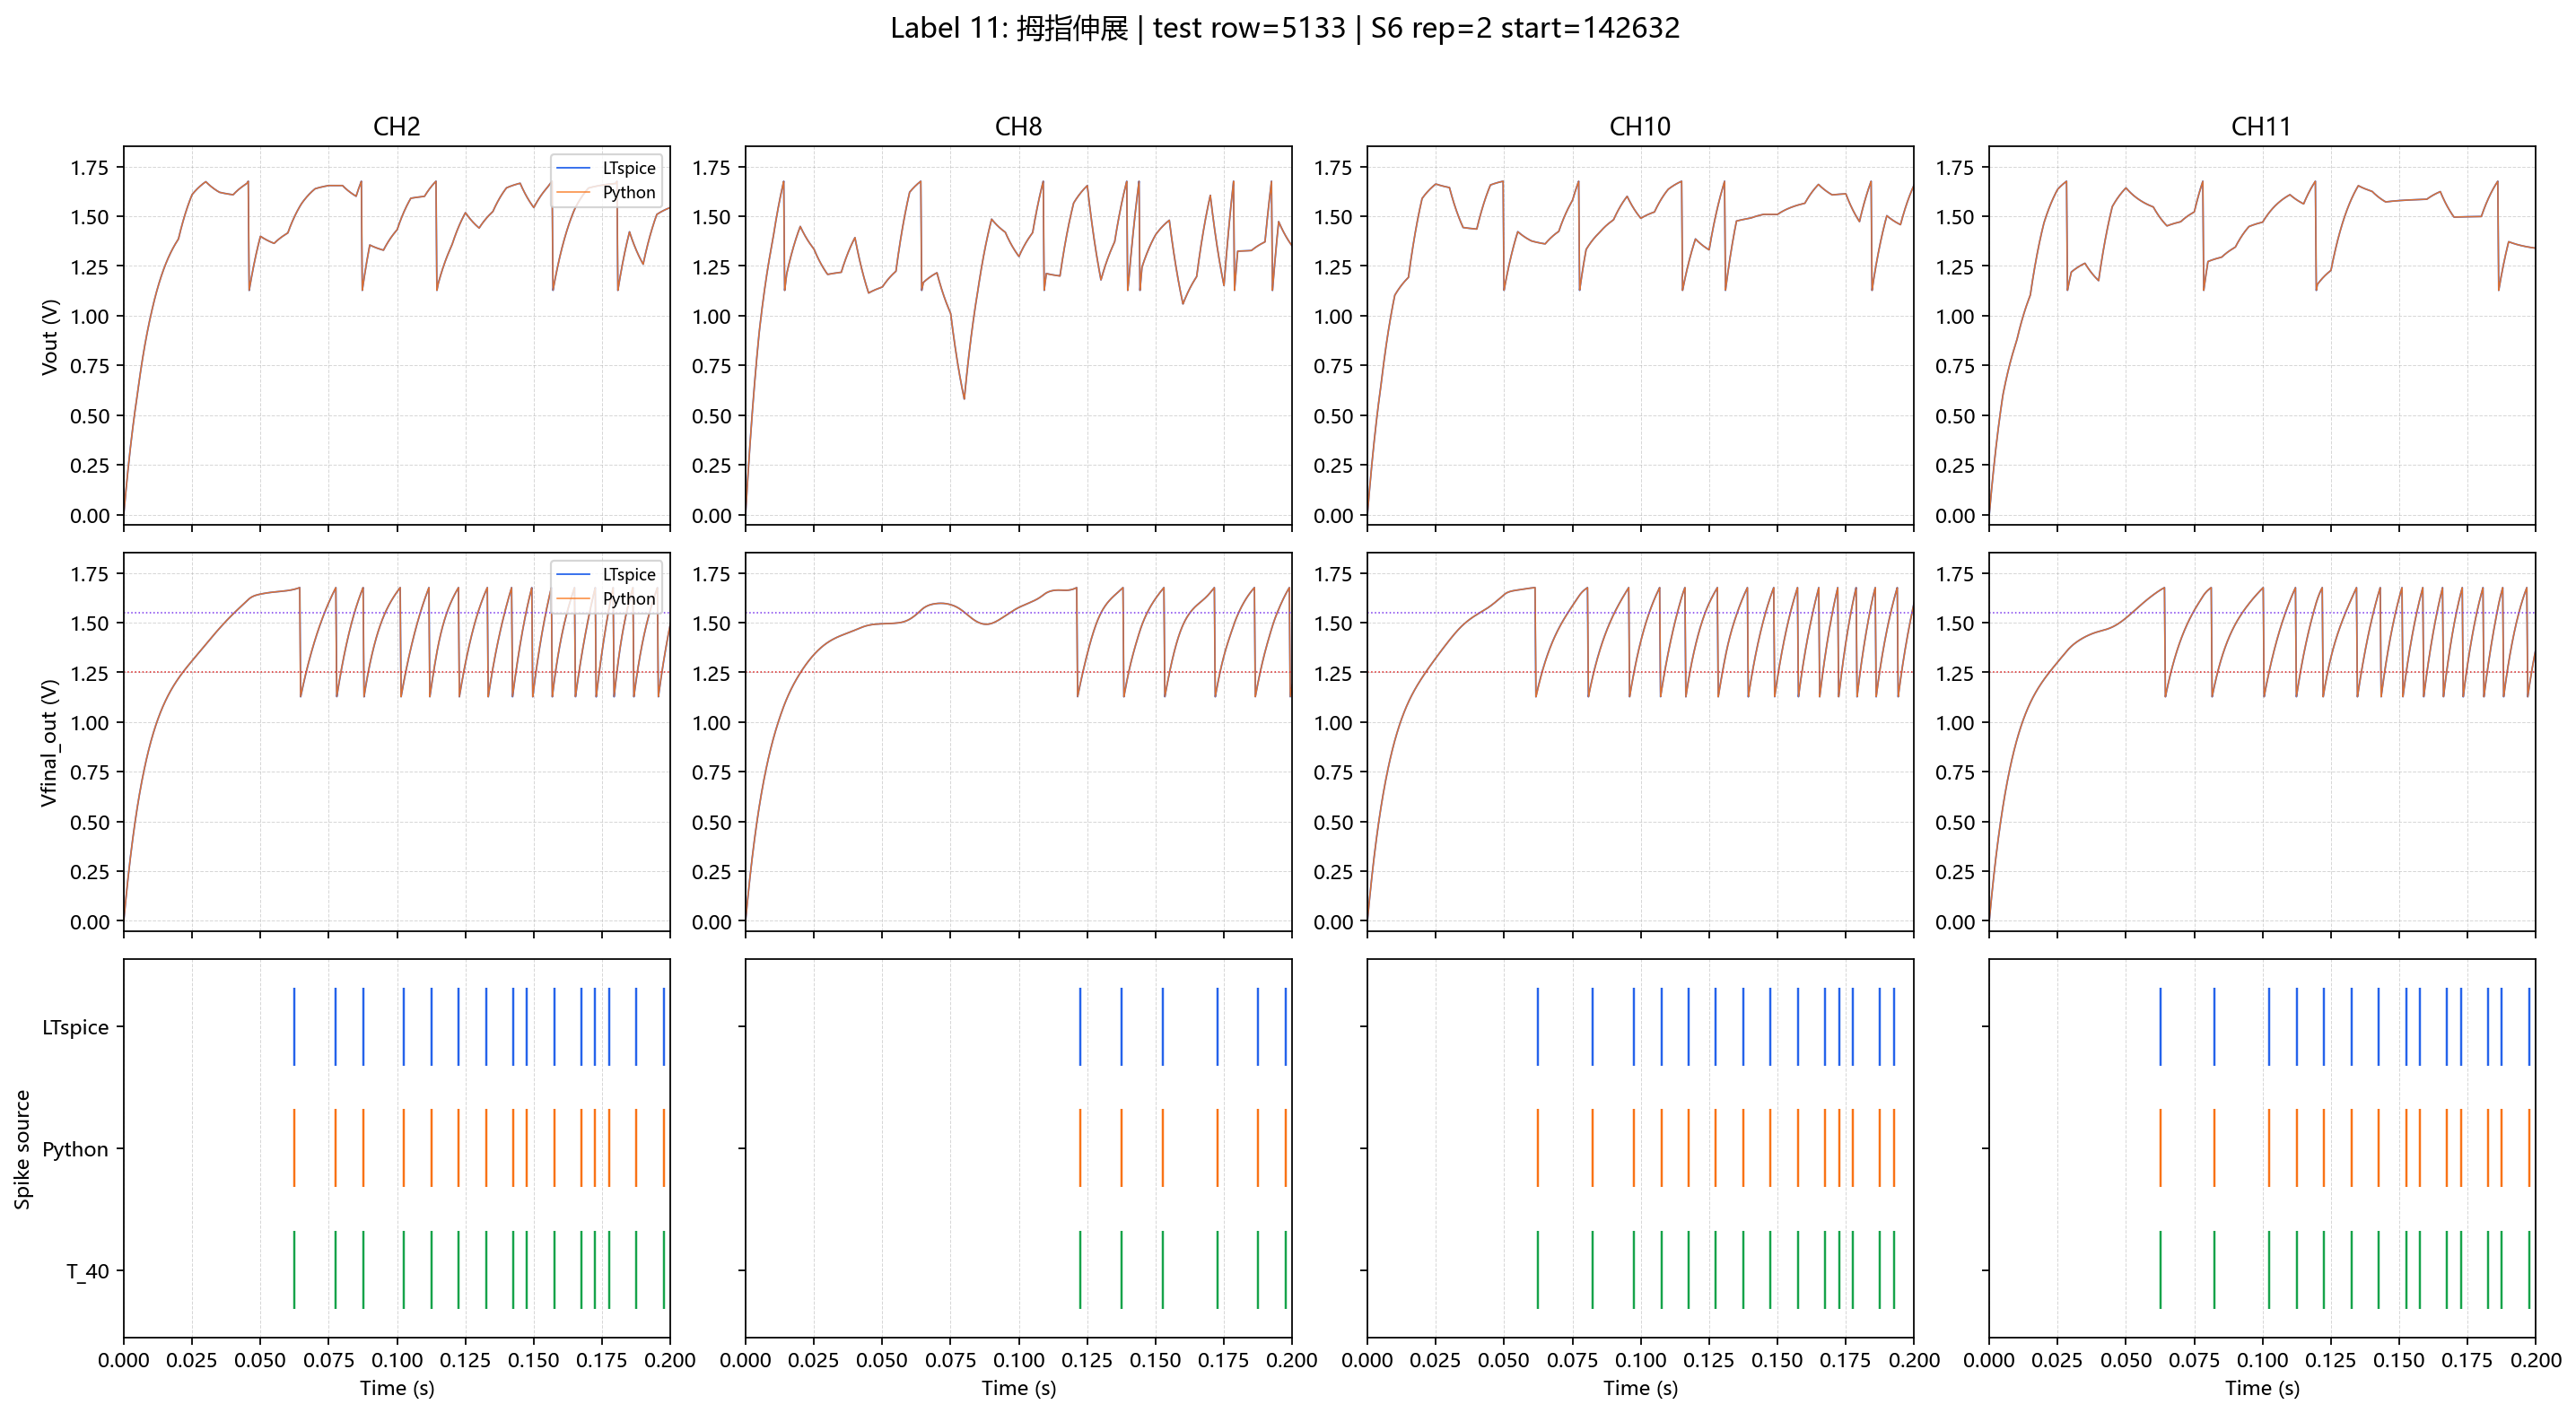

已生成12张动作对比图。


In [7]:
# 7. 为每个动作绘制Vout、Vfinal_out和三方脉冲编码
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei",
    "SimHei",
    "Noto Sans CJK SC",
    "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False

result_lookup = {
    (item["label"], item["channel"]): item
    for item in simulation_results
}
bin_centers = (
    np.arange(T, dtype=np.float64) + 0.5
) * BIN_DURATION
action_figure_paths = []

for selection in selection_records:
    label = selection["label"]
    figure, axes = plt.subplots(
        3,
        CHANNELS_TO_SELECT,
        figsize=(18, 10),
        dpi=130,
        sharex="col",
    )

    for column, channel in enumerate(SELECTED_CHANNELS):
        result = result_lookup[(label, channel)]

        axes[0, column].plot(
            result["lt_time"],
            result["lt_vout"],
            color="#2563eb",
            linewidth=0.8,
            label="LTspice",
        )
        axes[0, column].plot(
            result["py_time"],
            result["py_vout"],
            color="#f97316",
            linewidth=0.7,
            alpha=0.85,
            label="Python",
        )
        axes[0, column].set_title(f"CH{channel}")
        axes[0, column].set_ylim(-0.05, 1.85)
        axes[0, column].grid(
            True,
            linestyle="--",
            linewidth=0.45,
            alpha=0.5,
        )

        axes[1, column].plot(
            result["lt_time"],
            result["lt_final_out"],
            color="#2563eb",
            linewidth=0.8,
            label="LTspice",
        )
        axes[1, column].plot(
            result["py_time"],
            result["py_final_out"],
            color="#f97316",
            linewidth=0.7,
            alpha=0.85,
            label="Python",
        )
        axes[1, column].axhline(
            SPIKE_ARM,
            color="#7c3aed",
            linestyle=":",
            linewidth=0.7,
        )
        axes[1, column].axhline(
            SPIKE_FIRE,
            color="#dc2626",
            linestyle=":",
            linewidth=0.7,
        )
        axes[1, column].set_ylim(-0.05, 1.85)
        axes[1, column].grid(
            True,
            linestyle="--",
            linewidth=0.45,
            alpha=0.5,
        )

        spike_rows = (
            (2, result["lt_binary"], "#2563eb", "LTspice"),
            (1, result["py_binary"], "#f97316", "Python"),
            (0, result["saved_binary"], "#16a34a", "T_40"),
        )
        for row_value, binary, color, _ in spike_rows:
            active_times = bin_centers[np.flatnonzero(binary)]
            axes[2, column].vlines(
                active_times,
                row_value - 0.32,
                row_value + 0.32,
                color=color,
                linewidth=1.1,
            )
        axes[2, column].set_yticks([0, 1, 2])
        axes[2, column].set_yticklabels(
            ["T_40", "Python", "LTspice"]
            if column == 0
            else ["", "", ""]
        )
        axes[2, column].set_ylim(-0.55, 2.55)
        axes[2, column].set_xlim(0.0, WINDOW_DURATION)
        axes[2, column].set_xlabel("Time (s)")
        axes[2, column].grid(
            True,
            axis="x",
            linestyle="--",
            linewidth=0.45,
            alpha=0.5,
        )

    axes[0, 0].set_ylabel("Vout (V)")
    axes[1, 0].set_ylabel("Vfinal_out (V)")
    axes[2, 0].set_ylabel("Spike source")
    axes[0, 0].legend(loc="upper right", fontsize=8)
    axes[1, 0].legend(loc="upper right", fontsize=8)

    figure.suptitle(
        f"Label {label}: {selection['action_name_zh']} | "
        f"{selection['split']} row={selection['row_index']} | "
        f"S{selection['subject']} rep={selection['repetition']} "
        f"start={selection['start_sample']}",
        fontsize=14,
    )
    figure.tight_layout(rect=(0.0, 0.0, 1.0, 0.96))
    figure_path = (
        FIGURE_ROOT
        / f"label_{label:02d}_{selection['split']}_"
        f"row_{selection['row_index']:05d}.png"
    )
    figure.savefig(figure_path, dpi=160, bbox_inches="tight")
    plt.close(figure)
    action_figure_paths.append(figure_path)
    display(Image(filename=str(figure_path), width=1100))

print(f"已生成{len(action_figure_paths)}张动作对比图。")


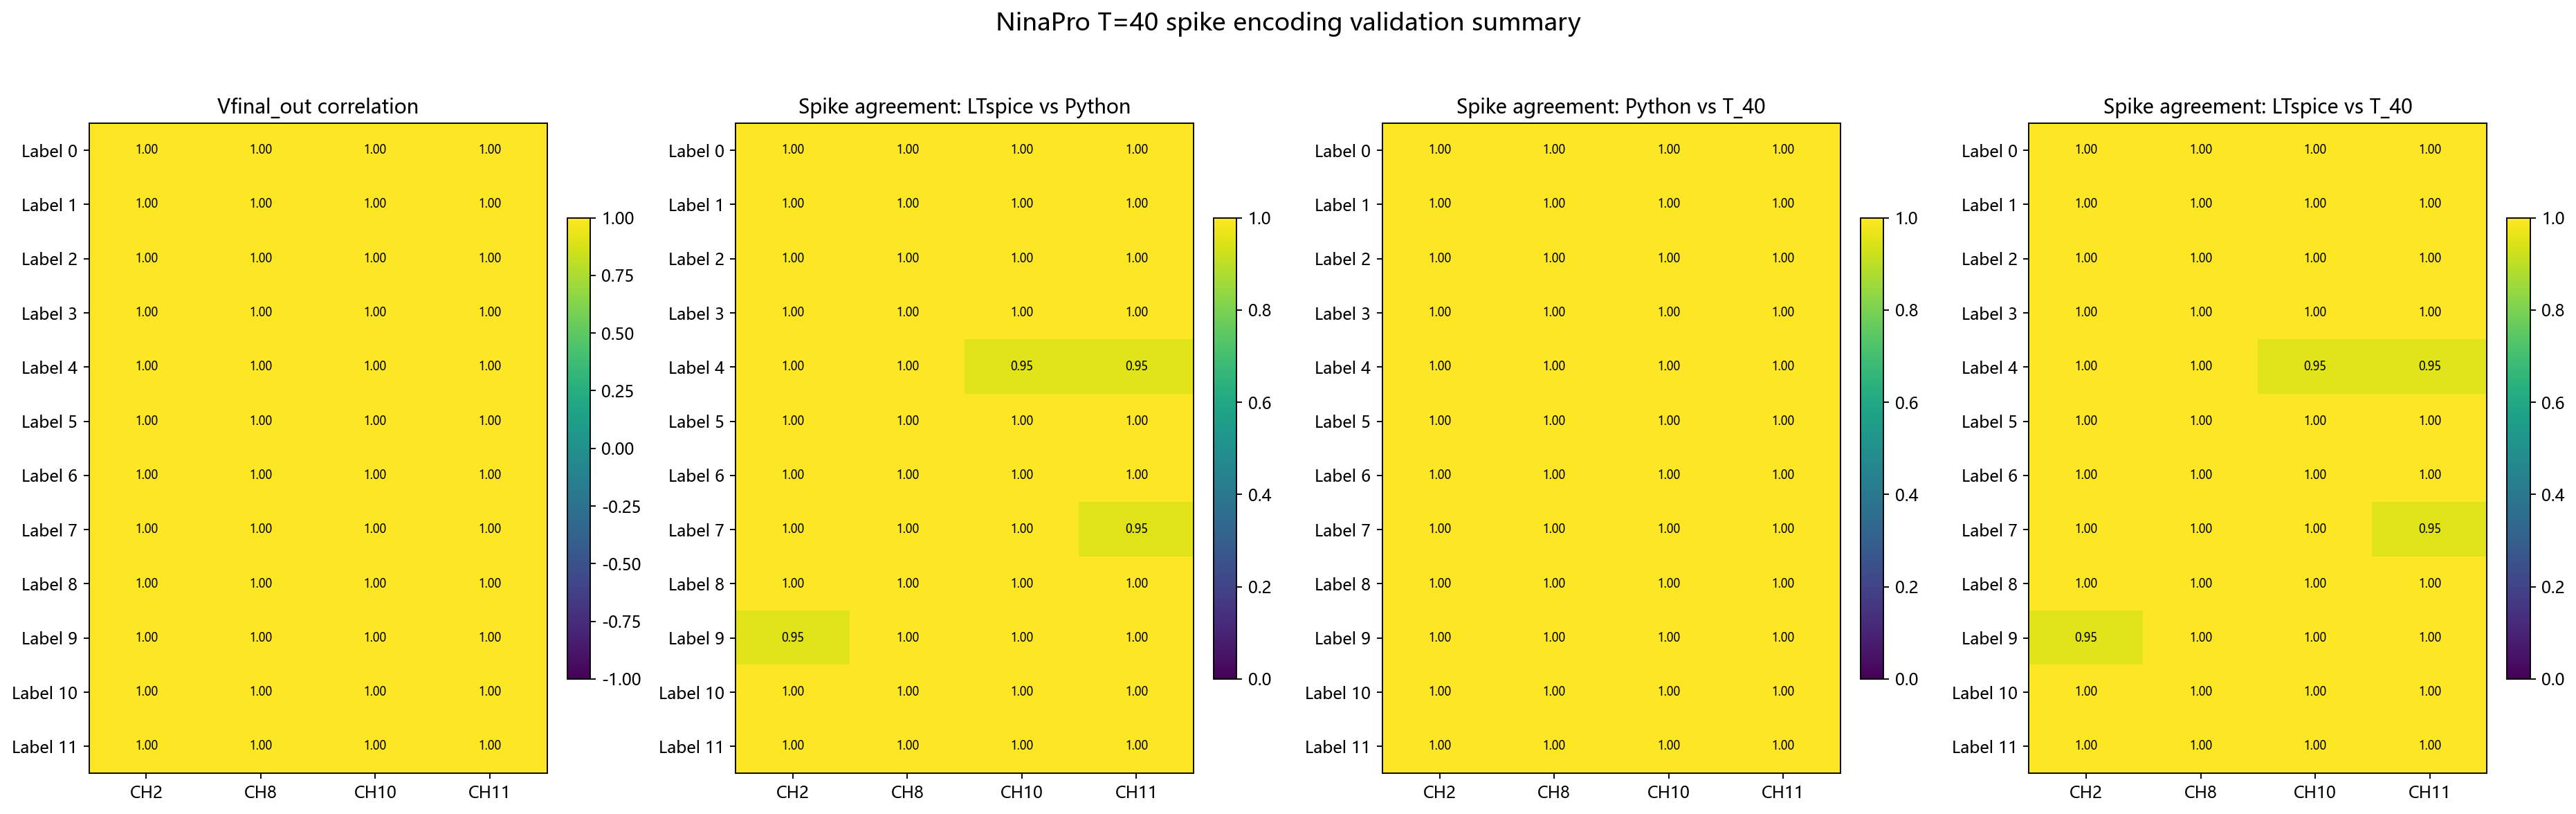

验证完成。
抽样清单：C:\Users\Fortyfour\Desktop\SNN_for_Ninapro\outputs\spike_encoding_validation\selection_manifest.csv
逐通道指标：C:\Users\Fortyfour\Desktop\SNN_for_Ninapro\outputs\spike_encoding_validation\validation_metrics.csv
汇总JSON：C:\Users\Fortyfour\Desktop\SNN_for_Ninapro\outputs\spike_encoding_validation\validation_summary.json
汇总图：C:\Users\Fortyfour\Desktop\SNN_for_Ninapro\outputs\spike_encoding_validation\validation_summary.png
硬性结论：所选48条通道序列的Python脉冲与T_40保存结果在二值编码和分箱计数上均逐元素一致。


In [8]:
# 8. 总体热图和最终结论
metric_lookup = {
    (item["label"], item["channel"]): item
    for item in metrics
}
matrix_names = (
    ("final_out_correlation", "Vfinal_out correlation", -1.0, 1.0),
    (
        "agreement_ltspice_python",
        "Spike agreement: LTspice vs Python",
        0.0,
        1.0,
    ),
    (
        "agreement_python_saved",
        "Spike agreement: Python vs T_40",
        0.0,
        1.0,
    ),
    (
        "agreement_ltspice_saved",
        "Spike agreement: LTspice vs T_40",
        0.0,
        1.0,
    ),
)

summary_figure, summary_axes = plt.subplots(
    1,
    4,
    figsize=(22, 7),
    dpi=130,
)
for axis, (field, title, minimum, maximum) in zip(
    summary_axes,
    matrix_names,
):
    matrix = np.asarray(
        [
            [
                metric_lookup[(label, channel)][field]
                for channel in SELECTED_CHANNELS
            ]
            for label in range(12)
        ],
        dtype=np.float64,
    )
    image = axis.imshow(
        matrix,
        aspect="auto",
        cmap="viridis",
        vmin=minimum,
        vmax=maximum,
    )
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            axis.text(
                column,
                row,
                f"{matrix[row, column]:.2f}",
                ha="center",
                va="center",
                fontsize=7,
                color=(
                    "white"
                    if np.isfinite(matrix[row, column])
                    and matrix[row, column]
                    < (minimum + maximum) / 2.0
                    else "black"
                ),
            )
    axis.set_title(title)
    axis.set_xticks(range(len(SELECTED_CHANNELS)))
    axis.set_xticklabels(
        [f"CH{channel}" for channel in SELECTED_CHANNELS]
    )
    axis.set_yticks(range(12))
    axis.set_yticklabels([f"Label {label}" for label in range(12)])
    summary_figure.colorbar(image, ax=axis, fraction=0.046, pad=0.04)

summary_figure.suptitle(
    "NinaPro T=40 spike encoding validation summary",
    fontsize=15,
)
summary_figure.tight_layout(rect=(0.0, 0.0, 1.0, 0.95))
summary_figure_path = RESULT_ROOT / "validation_summary.png"
summary_figure.savefig(
    summary_figure_path,
    dpi=170,
    bbox_inches="tight",
)
plt.close(summary_figure)
display(Image(filename=str(summary_figure_path), width=1400))

print("验证完成。")
print(f"抽样清单：{selection_manifest_path}")
print(f"逐通道指标：{metrics_path}")
print(f"汇总JSON：{summary_path}")
print(f"汇总图：{summary_figure_path}")
print(
    "硬性结论：所选48条通道序列的Python脉冲与T_40保存结果"
    "在二值编码和分箱计数上均逐元素一致。"
)
